### 1. 计算并比较效率

计算每个查询下每种方法相对于baseline_graph_only 的加速比：已经获得以下内容，为每个查询每个方法，计算每个查询每种方法的代价，已知记一次post采样后调用代理模型的速度为a，对应的oracle速度为A，一次comment采样后调用代理模型的速度为b，对应的oracle速度为B， 每个查询已知baseline_graph_only 方法调用的post和comment相关模型的n1,n2次数为基准，baseline_graph_only 的总时间开销计算为 n1/A + n2/B, 每个其他方法（proxy_importance、proxy_uniform、baseline_uniform 等）调用的post和comment次数为x1,x2, 每个方法的总时间开销为 n1/a + n2/b + x1/A + x2/B,写一个函数完成每个查询各方法时间的计算和输出 ，每个查询每种方法相对于baseline_graph_only 加速比，上面是模型默认速度值：

In [ ]:
import pandas as pd
import numpy as np
from typing import Union

def compute_query_speedups(
    data: Union[str, pd.DataFrame],
    A: float = 1.35 * 32,  # Post Oracle Speed
    B: float = 3.0 * 32,   # Comment Oracle Speed
    a: float = 17.0 * 32,  # Post Proxy Speed
    b: float = 31.0 * 32,  # Comment Proxy Speed
    save_csv: Union[None, str] = None,
    verbose: bool = True
) -> pd.DataFrame:
    """
    计算每个查询下每种方法的时间开销并相对于 baseline_graph_only 的加速比。

    公式（如题述）：
      baseline_time = n1 / A + n2 / B
      method_time   = n1 / a + n2 / b + x1 / A + x2 / B
    其中：
      - n1,n2: 对应 query 的 baseline_graph_only 的 post/comment 次数（基准）
      - x1,x2: 当前方法的 post/comment 次数

    参数：
      data: CSV 文件路径 或 pandas.DataFrame，必须包含列
            ['query_name','method','post_sampled_cnt','comment_sampled_cnt']
      A,B,a,b: 速度参数（默认使用你给的值）
      save_csv: 若不为 None，则把结果保存到该路径
      verbose: 是否打印警告/摘要信息

    返回：
      DataFrame 包含以下列：
        query (base query name, 去掉 .graph 后缀)
        query_name (原始)
        method
        post_sampled_cnt (x1)
        comment_sampled_cnt (x2)
        baseline_post_n1
        baseline_comment_n2
        baseline_time
        method_time
        speedup   (baseline_time / method_time; baseline -> 1.0)
    """
    # 读取或验证 DataFrame
    if isinstance(data, str):
        df = pd.read_csv(data)
    else:
        df = data.copy()

    required_cols = {'query_name', 'method', 'post_sampled_cnt', 'comment_sampled_cnt'}
    if not required_cols.issubset(set(df.columns)):
        missing = required_cols - set(df.columns)
        raise ValueError(f"输入缺少列: {missing}")

    # 规范列类型为浮点数以便计算
    df['post_sampled_cnt'] = pd.to_numeric(df['post_sampled_cnt'], errors='coerce')
    df['comment_sampled_cnt'] = pd.to_numeric(df['comment_sampled_cnt'], errors='coerce')

    # 构建 baseline 映射：key = base_query(去掉 .graph 后缀) -> (n1,n2)
    baseline_rows = df[df['method'] == 'baseline_graph_only'].copy()
    if baseline_rows.empty and verbose:
        print("[警告] 输入中没有 method == 'baseline_graph_only' 的行，无法计算基准。")
    baseline_rows['base_query'] = baseline_rows['query_name'].astype(str).str.replace('.graph', '', regex=False)
    base_map = baseline_rows.set_index('base_query')[['post_sampled_cnt', 'comment_sampled_cnt']].to_dict('index')

    records = []
    for _, row in df.iterrows():
        qname = str(row['query_name'])
        method = str(row['method'])
        base_q = qname.replace('.graph', '')  # 对应的基准 query key
        x1 = float(row['post_sampled_cnt']) if not np.isnan(row['post_sampled_cnt']) else np.nan
        x2 = float(row['comment_sampled_cnt']) if not np.isnan(row['comment_sampled_cnt']) else np.nan

        if base_q not in base_map:
            # baseline 缺失：填 NaN，并跳过 speedup 计算
            n1 = np.nan
            n2 = np.nan
            baseline_time = np.nan
            method_time = np.nan
            speedup = np.nan
            if verbose:
                print(f"[提示] query '{qname}' 对应的 baseline_graph_only 未找到，方法 '{method}' 的 speedup 设为 NaN。")
        else:
            n1 = float(base_map[base_q]['post_sampled_cnt'])
            n2 = float(base_map[base_q]['comment_sampled_cnt'])
            baseline_time = n1 / A + n2 / B

            if method == 'baseline_graph_only':
                method_time = baseline_time
                speedup = 1.0
            else:
                # method time = n1/a + n2/b + x1/A + x2/B
                method_time = n1 / a + n2 / b + (x1 / A if not np.isnan(x1) else np.nan) + (x2 / B if not np.isnan(x2) else np.nan)
                # 避免除以 0
                if method_time == 0 or np.isnan(method_time) or np.isnan(baseline_time):
                    speedup = np.nan
                else:
                    speedup = baseline_time / method_time

        records.append({
            'query': base_q,
            'method': method,
            'post_sampled_cnt': x1,
            'comment_sampled_cnt': x2,
            'baseline_post_n1': n1,
            'baseline_comment_n2': n2,
            'baseline_time': baseline_time,
            'method_time': method_time,
            'speedup': speedup
        })

    out = pd.DataFrame.from_records(records)

    # 排序：按 query, speedup 降序（方便查看最快方法）
    out = out.sort_values(by=['query', 'speedup'], ascending=[True, False]).reset_index(drop=True)

    if save_csv is not None:
        out.to_csv(save_csv, index=False)
        if verbose:
            print(f"[保存] 结果已保存到: {save_csv}")

    return out

# ---------------------------
# 使用示例（如果你有 CSV 文件）：
dataset_name = 'dataset_three'
df_result = compute_query_speedups(f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency/sampled_node_count.csv")
print(df_result.head(50).to_string(index=False))

# ---- 计算每个方法在所有查询中的平均、最高加速比 ----
method_stats = (
    df_result.groupby("method")["speedup"]
    .agg(avg_speedup="mean", max_speedup="max")
    .sort_values(by="avg_speedup", ascending=False)
)

# ---- 打印结果 ----
print("\n===== 每个方法在所有查询中的平均加速比 & 最高加速比 =====")
for method, row in method_stats.iterrows():
    print(
        f"{method:20s}  "
        f"avg_speedup = {row['avg_speedup']:.4f}   "
        f"max_speedup = {row['max_speedup']:.4f}"
    )
# ----------------------------------------------

### 2. 计算并比较单次运行结果的精度

#### 2.0 误差棒

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

dataset_name ='dataset_one'
csv_file = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/ML2_proxy1d1_results_summary.csv"
df = pd.read_csv(csv_file)

# --- 按方法对 Qerror_mean 和 Qerror_std 进行分组聚合 ---
# 我们需要的是每种方法在所有查询上的 Qerror 的总体均值和标准差
# 这可以通过对原始 Qerror_mean 和 Qerror_std 再求一次平均得到
summary = df.groupby('method').agg(
    avg_qerror_mean=('Qerror_mean', 'mean'),
    avg_qerror_std=('Qerror_std', 'mean') # 注意：这里是对std求均值，作为一种近似
).reset_index()

# 排序，让图更好看
summary = summary.sort_values(by='avg_qerror_mean')

# --- 绘制误差范围图 ---
plt.figure(figsize=(12, 7))

# yerr 参数用于指定误差棒的长度
plt.errorbar(
    x=summary['method'], 
    y=summary['avg_qerror_mean'], 
    yerr=summary['avg_qerror_std'],
    fmt='o',          # 'o' 表示用点来标记均值
    capsize=5,        # 误差棒顶部的横线宽度
    capthick=2,
    elinewidth=2,
    ms=8,             # 标记点的大小
    label='Mean Q-error ± Std Dev'
)

plt.title('Overall Performance of Sampling Methods', fontsize=16)
plt.xlabel('Method', fontsize=12)
plt.ylabel('Q-error (Mean ± Std Dev) - Lower is Better', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

#### 2.1 箱型图绘制0 -- 基于平均绝对值误差 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Optional
class MAPEBoxplotVisualizer:
    """
    封装 MAPE 箱型图绘制流程：
        - 读取 summary CSV
        - 计算 query_type
        - 生成 2 张箱型图（总体、按 query 类型分色）
    """

    def __init__(self, csv_file: str, dataset_name: str = "dataset_test"):
        self.csv_file = csv_file
        self.dataset_name = dataset_name
        self.df: Optional[pd.DataFrame] = None

        # 默认输出文件名
        self.save_fig_all = "MAPE_boxplot_overall.png"
        self.save_fig_bytype = "MAPE_boxplot_by_querytype.png"

    # ----------------------------------------------------------------------
    def load_and_preprocess(self):
        """读取 CSV 并计算 query_type、log10_Qerror_mean"""
        try:
            df = pd.read_csv(self.csv_file)
        except FileNotFoundError:
            print(f"[错误] 文件未找到: {self.csv_file}")
            raise

        # 提取查询类型
        df["query_type"] = df["query_basename"].apply(
            lambda x: x.split("_")[1] if "_" in x else "unknown"
        )

        # 避免 log10(0)
        df["log10_Qerror_mean"] = np.log10(df["Qerror_mean"] + 1e-9)

        self.df = df

        print(f"[INFO] 数据加载成功，共 {len(df)} 行")
        return df

    # ----------------------------------------------------------------------
    def _set_global_style(self):
        """设置 seaborn 全局风格"""
        sns.set_theme(
            style="whitegrid",
            font_scale=1.3,
            rc={
                "axes.facecolor": "white",
                "axes.edgecolor": "gray",
                "grid.color": "lightgray",
                "axes.linewidth": 1.2,
                "figure.figsize": (14, 8)
            }
        )

    # ----------------------------------------------------------------------
    def plot_overall_boxplot(self):
        """绘制图1：总体箱型图"""
        df = self.df
        if df is None:
            raise ValueError("请先调用 load_and_preprocess()")

        self._set_global_style()

        plt.figure(figsize=(16, 12))
        ax = sns.boxplot(
            data=df,
            x="method",
            y="Qerror_mean",
            palette="viridis",
            showmeans=True,
            width=0.6,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
            boxprops={"alpha": 0.8, "linewidth": 1.5},
            medianprops={"color": "red", "linewidth": 2},
            flierprops={"marker": "x", "color": "gray", "alpha": 0.4, "markersize": 5},
        )

        ax.set_title("Overall Accuracy Distribution (MAPE)", fontsize=16, fontweight="bold")
        ax.set_xlabel("Estimation Method", fontsize=13)
        ax.set_ylabel("Qerror_mean (MAPE)", fontsize=13)

        # y轴范围
        y_limit = df["Qerror_mean"].quantile(0.95)
        ax.set_ylim(bottom=0, top=y_limit * 1.1)

        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.savefig(self.save_fig_all, dpi=300)
        plt.show()

        print(f"[INFO] 图1 保存为: {self.save_fig_all}")

    # ----------------------------------------------------------------------
    def plot_boxplot_by_querytype(self):
        """绘制图2：按 query_type 分色"""
        df = self.df
        if df is None:
            raise ValueError("请先调用 load_and_preprocess()")

        self._set_global_style()

        plt.figure(figsize=(14, 8))
        ax = sns.boxplot(
            data=df,
            x="method",
            y="Qerror_mean",
            hue="query_type",
            palette="plasma",
            showmeans=True,
            width=0.7,
            meanprops={"marker": "D", "markerfacecolor": "black", "markeredgecolor": "black"},
            medianprops={"color": "darkred", "linewidth": 2},
            flierprops={"marker": "x", "color": "gray", "alpha": 0.4},
        )

        ax.set_title("Accuracy Distribution by Method and Query Type (MAPE)",
                     fontsize=16, fontweight="bold")
        ax.set_xlabel("Estimation Method", fontsize=13)
        ax.set_ylabel("Qerror_mean (MAPE)", fontsize=13)
        ax.legend(title="Query Type", loc="upper right", fontsize=11, title_fontsize=12)

        y_limit = df["Qerror_mean"].quantile(0.95)
        ax.set_ylim(bottom=0, top=y_limit * 1.1)

        plt.xticks(rotation=10)
        plt.tight_layout()
        plt.savefig(self.save_fig_bytype, dpi=300)
        plt.show()

        print(f"[INFO] 图2 保存为: {self.save_fig_bytype}")

    # ----------------------------------------------------------------------
    def run_all(self):
        """一键运行所有流程"""
        self.load_and_preprocess()
        self.plot_overall_boxplot()
        self.plot_boxplot_by_querytype()
dataset_name = "dataset_test"
csv_file = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/results_summary_0_manytimes.csv"

vis = MAPEBoxplotVisualizer(csv_file, dataset_name)
vis.run_all()

##### 2.1.1 箱型图绘制1 -- 基于相对误差：(df["T_hat_mean"] - df["T_true"]) / df["T_true"]

(1) 红线：中位数 (Median) 它表示有50%的数据点小于或等于这个值，另外50%的数据点大于或等于这个值。
(2) 黑点：均值 (Mean)这个黑点代表了数据的算术平均值（Mean）。它是所有数据点之和除以数据点总数的结果。在数据分布对称时，均值和中位数会非常接近。如果分布不对称（有偏斜），均值会偏向数据分布较长的那一侧。
(3) 黑叉：离群值/异常值 (Outliers/Fliers)含义：这些黑叉代表了离群值（Outliers），也常被称为“异常值”。它们是那些远离数据主体、数值异常大或异常小的点。在统计学上，通常定义为超出以下范围的数据点：
上限：Q3 + 1.5 * IQR
下限：Q1 - 1.5 * IQR
其中，Q1是下四分位数（25%位置的数值），Q3是上四分位数（75%位置的数值），IQR是四分位距（IQR = Q3 - Q1）。简单来说，这些黑叉就是数据集中与其他数据相比显得“不合群”的点。

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
signed_error_visualizer.py

Uses a class-based approach to draw boxplots for Signed Relative Error 
((T_hat - T_true) / T_true).

This refactored script provides full control over the Y-axis limits and ticks
directly from the main function's configuration block.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from typing import List, Tuple, Optional

class SignedErrorVisualizer:
    """
    Encapsulates the entire process for analyzing and visualizing
    Signed Relative Error.
    """
    def __init__(self, csv_file: str, output_dir: str):
        """
        Initializes the visualizer.

        Args:
            csv_file (str): The path to the input CSV data file.
            output_dir (str): The directory where output files will be saved.
        """
        self.csv_file = csv_file
        self.output_dir = output_dir
        self.df = None

        sns.set_theme(
            style="whitegrid", font_scale=1.3,
            rc={"axes.facecolor": "white", "axes.edgecolor": "gray", "grid.color": "lightgray"}
        )
        os.makedirs(self.output_dir, exist_ok=True)
        print(f"[INFO] Output directory confirmed: {self.output_dir}")

    def _load_and_preprocess_data(self):
        """
        Private method to load the CSV and compute the Signed Relative Error.
        """
        print(f"[INFO] Reading data from: {self.csv_file}")
        if not os.path.exists(self.csv_file):
            raise FileNotFoundError(f"[ERROR] Input file not found: {self.csv_file}")
        
        df = pd.read_csv(self.csv_file)

        # Calculate Signed Relative Error (referred to as Qerror_signed in original script)
        df["signed_relative_error"] = np.where(
            df["T_true"] != 0, 
            (df["T_hat_mean"] - df["T_true"]) / df["T_true"],
            df["T_hat_mean"]  # If T_true=0, error is the estimate itself
        )

        # Extract query type
        df["query_type"] = df["query_basename"].apply(
            lambda x: x.split("_")[1] if "_" in x else "unknown"
        )
        
        self.df = df
        print("[INFO] ✅ Data preprocessing complete.")

    def _plot_error_boxplot(self, save_path: str, title: str, **kwargs):
        """
        A generic private method for plotting boxplots with custom axis control.
        """
        # Pop all custom parameters to avoid passing them to sns.boxplot
        figsize = kwargs.pop("figsize", (16, 10))
        xlabel = kwargs.pop("xlabel", "Estimation Method")
        legend_title = kwargs.pop("legend_title", "Legend")
        y_lim = kwargs.pop("y_lim", None)
        y_ticks = kwargs.pop("y_ticks", None)
        
        plt.figure(figsize=figsize)
        
        # Handle FutureWarning by assigning x to hue if hue is not specified
        if "hue" not in kwargs and "x" in kwargs:
            kwargs["hue"] = kwargs["x"]
            kwargs["legend"] = False

        ax = sns.boxplot(
            data=self.df,
            palette="Set2",
            showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
            medianprops={"color": "red", "linewidth": 2},
            flierprops={"marker": "x", "color": "gray", "alpha": 0.4, "markersize": 5},
            **kwargs
        )
        
        # The baseline for signed error is 0
        ax.axhline(0, color="gray", linestyle="--", linewidth=1.5)

        ax.set_title(title, fontsize=16, fontweight="bold")
        ax.set_xlabel(xlabel, fontsize=13)
        ax.set_ylabel("(T_hat - T_true) / T_true", fontsize=13)
        
        # Apply custom Y-axis settings if provided
        if y_lim:
            ax.set_ylim(y_lim)
        if y_ticks:
            ax.set_yticks(y_ticks)
        
        if kwargs.get("legend", True):
             ax.legend(title=legend_title, loc="upper right", fontsize=11, title_fontsize=12, frameon=True, edgecolor="gray")
        
        plt.xticks(rotation=10)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"[INFO] ✅ Chart saved to: {save_path}")

    def _generate_outlier_report(self):
        """
        Private method to calculate and save the outlier statistics report.
        """
        error_col = "signed_relative_error"
        save_path = os.path.join(self.output_dir, "SignedError_outlier_report.csv")
        outlier_stats = []

        for method, group_data in self.df.groupby('method'):
            col_data = group_data[error_col].dropna()
            if len(col_data) == 0: continue

            Q1, Q3 = col_data.quantile(0.25), col_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
            
            outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
            
            total_count, outlier_count = len(group_data), len(outliers)
            outlier_ratio = (outlier_count / total_count) * 100 if total_count > 0 else 0
            
            outlier_stats.append({
                'Method': method, 'Total Queries': total_count,
                'Outlier Count': outlier_count, 'Outlier Ratio (%)': outlier_ratio
            })
        
        report_df = pd.DataFrame(outlier_stats).sort_values(by='Outlier Ratio (%)')

        print("\n" + "="*50)
        print(f"====== Outlier Statistics Report for '{error_col}' ======")
        print(report_df.to_string(index=False))
        report_df.to_csv(save_path, index=False)
        print(f"\n[INFO] ✅ Outlier report saved to: {save_path}")
        print("="*50)

    def run_analysis(self, y_lim: Optional[Tuple[float, float]], y_ticks: Optional[List[float]]):
        """
        Public method to execute the full analysis and plotting workflow.

        Args:
            y_lim (Optional[Tuple[float, float]]): Y-axis limits, e.g., (-1.0, 1.0).
            y_ticks (Optional[List[float]]): Y-axis tick locations, e.g., [-1, -0.5, 0, 0.5, 1].
        """
        try:
            self._load_and_preprocess_data()
            
            plot_settings = {"y_lim": y_lim, "y_ticks": y_ticks}
            
            print(f"\n--- Generating Signed Relative Error plots with settings: {plot_settings} ---")
            
            # Plot 1: Overall comparison
            self._plot_error_boxplot(
                save_path=os.path.join(self.output_dir, "SignedError_boxplot_overall.png"),
                title="Overall Signed Relative Error Distribution",
                x="method", y="signed_relative_error", figsize=(16, 12), xlabel="Estimation Method",
                **plot_settings
            )

            # # Plot 2: Colored by query type
            # self._plot_error_boxplot(
            #     save_path=os.path.join(self.output_dir, "SignedError_boxplot_by_querytype.png"),
            #     title="Signed Relative Error by Method and Query Type",
            #     x="method", y="signed_relative_error", hue="query_type", legend_title="Query Structure", xlabel="Estimation Method",
            #     **plot_settings
            # )
            # 
            # # Plot 3: Grouped by query type
            # self._plot_error_boxplot(
            #     save_path=os.path.join(self.output_dir, "SignedError_boxplot_grouped_by_querytype.png"),
            #     title="Signed Relative Error by Query Type and Method",
            #     x="query_type", y="signed_relative_error", hue="method", legend_title="Estimation Method", xlabel="Query Structure Type",
            #     **plot_settings
            # )
            
            self._generate_outlier_report()
            
            print("\n[SUCCESS] All analysis and visualization tasks completed successfully!")

        except FileNotFoundError as e:
            print(e)
        except Exception as e:
            print(f"[FATAL ERROR] An unexpected error occurred during analysis: {e}")

# =========================
# 🎯 Main execution block
# =========================
def main():
    """Main function to configure and run the analysis."""
    # --- Data Configuration ---
    dataset_name = 'dataset_one'
    # input_csv = os.path.join(base_path, "results_summary_1_singletime.csv")
    # input_csv = os.path.join(base_path, "results_summary_merged.csv")
    base_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/result_summarys"
    input_csv = os.path.join(base_path, "results_summary_run_9_20251213.csv")
    output_directory = base_path + f"/images/{dataset_name}_ratio_error_analysis_results"


    # --- Plotting Configuration ---
    # Freely control the Y-axis for all plots here
    
    # Example 1: Set a specific range and ticks (default from original script)
    Y_AXIS_LIMITS = (-1.0, 1.0)
    Y_AXIS_TICKS = [-1.0, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0]

    # Example 2: A wider range
    # Y_AXIS_LIMITS = (-2.0, 2.0)
    # Y_AXIS_TICKS = [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2]

    # Example 3: Automatic mode (let matplotlib decide)
    # Y_AXIS_LIMITS = None
    # Y_AXIS_TICKS = None

    # --- Run Analysis ---
    visualizer = SignedErrorVisualizer(csv_file=input_csv, output_dir=output_directory)
    visualizer.run_analysis(
        y_lim=Y_AXIS_LIMITS,
        y_ticks=Y_AXIS_TICKS
    )

if __name__ == "__main__":
    main()

##### 2.1.2 Q_error

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
ratio_error_visualizer_custom_axis.py

使用一个封装良好的类来执行 Estimation Ratio (T_hat / T_true) 的分析和可视化。
该版本提供了对Y轴的完全控制，允许用户在主函数中自定义坐标轴类型（线性/对数）、
范围和刻度。
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from typing import List, Tuple, Optional

class RatioAnalysisVisualizer:
    """
    一个用于分析和可视化 Estimation Ratio (T_hat / T_true) 的类。
    提供灵活的坐标轴控制。
    """
    def __init__(self, csv_file: str, output_dir: str):
        """
        初始化分析器。

        Args:
            csv_file (str): 输入的 CSV 文件路径。
            output_dir (str): 保存所有输出文件的目录。
        """
        self.csv_file = csv_file
        self.output_dir = output_dir
        self.df = None

        sns.set_theme(
            style="whitegrid", font_scale=1.3,
            rc={"axes.facecolor": "white", "axes.edgecolor": "gray", "grid.color": "lightgray"}
        )
        os.makedirs(self.output_dir, exist_ok=True)
        print(f"[INFO] 输出目录已确认: {self.output_dir}")

    def _load_and_preprocess_data(self):
        """
        私有方法：加载数据并计算 Estimation Ratio。
        """
        print(f"[INFO] 正在读取数据: {self.csv_file}")
        if not os.path.exists(self.csv_file):
            raise FileNotFoundError(f"[错误] 输入文件未找到: {self.csv_file}")
        
        df = pd.read_csv(self.csv_file)

        with np.errstate(divide='ignore', invalid='ignore'):
            df['estimation_ratio'] = np.divide(df['T_hat_mean'], df['T_true'])

        df.loc[(df['T_true'] == 0) & (df['T_hat_mean'] == 0), 'estimation_ratio'] = 1.0
        
        df["query_type"] = df["query_basename"].apply(
            lambda x: x.split("_")[1] if "_" in x else "unknown"
        )
        
        self.df = df
        print("[INFO] ✅ 数据预处理完成，已计算 'estimation_ratio'。")

    def _plot_ratio_boxplot(self, save_path: str, title: str, **kwargs):
        """
        私有方法：绘制 Estimation Ratio 箱型图，支持自定义坐标轴。
        """
        # --- 弹出所有自定义参数，避免传递给 sns.boxplot ---
        figsize = kwargs.pop("figsize", (16, 10))
        xlabel = kwargs.pop("xlabel", "Estimation Method")
        legend_title = kwargs.pop("legend_title", "Legend")
        
        # --- 新增：弹出Y轴控制参数 ---
        use_log_scale = kwargs.pop("use_log_scale", False)
        y_lim = kwargs.pop("y_lim", None)
        y_ticks = kwargs.pop("y_ticks", None)
        
        plt.figure(figsize=figsize)
        
        if "hue" not in kwargs and "x" in kwargs:
            kwargs["hue"] = kwargs["x"]
            kwargs["legend"] = False

        ax = sns.boxplot(
            data=self.df,
            palette="Set2",
            showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "black", "markeredgecolor": "black"},
            medianprops={"color": "red", "linewidth": 2},
            flierprops={"marker": "x", "color": "gray", "alpha": 0.4},
            **kwargs
        )
        
        # --- 根据参数动态设置Y轴 ---
        if use_log_scale:
            ax.set_yscale('log')
            final_title = f"{title} (Log Scale)"
            ylabel = "Estimation Ratio (T_hat / T_true) [Log Scale]"
        else:
            final_title = title
            ylabel = "Estimation Ratio (T_hat / T_true)"

        ax.axhline(1, color="gray", linestyle="--", linewidth=1.5)

        ax.set_title(final_title, fontsize=16, fontweight="bold")
        ax.set_xlabel(xlabel, fontsize=13)
        ax.set_ylabel(ylabel, fontsize=13)
        
        if y_lim:
            ax.set_ylim(y_lim)
        if y_ticks:
            ax.set_yticks(y_ticks)
        
        if kwargs.get("legend", True):
             ax.legend(title=legend_title, loc="upper right", fontsize=11, title_fontsize=12, frameon=True, edgecolor="gray")
        
        plt.xticks(rotation=10)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"[INFO] ✅ 图表已保存: {save_path}")

    def _generate_outlier_report(self):
        """私有方法：为 estimation_ratio 列生成并保存异常值报告。"""
        # (此函数无需修改)
        error_col = "estimation_ratio"
        save_path = os.path.join(self.output_dir, "RatioError_outlier_report.csv")
        outlier_stats = []

        for method, group_data in self.df.groupby('method'):
            col_data = group_data[error_col].replace([np.inf, -np.inf], np.nan).dropna()
            if len(col_data) == 0: continue

            Q1, Q3 = col_data.quantile(0.25), col_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
            
            outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
            
            total_count, outlier_count = len(group_data), len(outliers)
            outlier_ratio = (outlier_count / total_count) * 100 if total_count > 0 else 0
            
            outlier_stats.append({
                'Method': method, 'Total Queries': total_count,
                'Outlier Count': outlier_count, 'Outlier Ratio (%)': outlier_ratio
            })
        
        report_df = pd.DataFrame(outlier_stats).sort_values(by='Outlier Ratio (%)')

        print("\n" + "="*50)
        print(f"====== '{error_col}' 奇异值 (Outlier) 统计报告 ======")
        print(report_df.to_string(index=False))
        report_df.to_csv(save_path, index=False)
        print(f"\n[INFO] ✅ 奇异值报告已保存为: {save_path}")
        print("="*50)

    def run_analysis(self, use_log_scale: bool, y_lim: Optional[Tuple[float, float]], y_ticks: Optional[List[float]]):
        """
        公共方法：执行完整的分析流程。

        Args:
            use_log_scale (bool): 是否为Y轴启用对数刻度。
            y_lim (Optional[Tuple[float, float]]): Y轴的范围, e.g., (0, 2.5)。
            y_ticks (Optional[List[float]]): Y轴的刻度列表, e.g., [0, 0.5, 1, 1.5, 2]。
        """
        try:
            self._load_and_preprocess_data()
            
            # 将所有绘图设置打包到一个字典中
            plot_settings = {
                "use_log_scale": use_log_scale,
                "y_lim": y_lim,
                "y_ticks": y_ticks
            }
            
            print(f"\n--- 开始生成 Estimation Ratio 图表 (使用配置: {plot_settings}) ---")
            
            # 将通用设置传递给所有绘图函数
            self._plot_ratio_boxplot(
                save_path=os.path.join(self.output_dir, "RatioError_boxplot_overall.png"),
                title="Overall Estimation Ratio Distribution",
                x="method", y="estimation_ratio", figsize=(16, 12), xlabel="Estimation Method",
                **plot_settings
            )

            self._plot_ratio_boxplot(
                save_path=os.path.join(self.output_dir, "RatioError_boxplot_by_querytype.png"),
                title="Estimation Ratio by Method and Query Type",
                x="method", y="estimation_ratio", hue="query_type", legend_title="Query Structure", xlabel="Estimation Method",
                **plot_settings
            )

            self._plot_ratio_boxplot(
                save_path=os.path.join(self.output_dir, "RatioError_boxplot_grouped_by_querytype.png"),
                title="Estimation Ratio by Query Type and Method",
                x="query_type", y="estimation_ratio", hue="method", legend_title="Estimation Method", xlabel="Query Structure Type",
                **plot_settings
            )
            
            self._generate_outlier_report()
            
            print("\n[SUCCESS] 所有分析和可视化任务已成功完成！")

        except FileNotFoundError as e:
            print(e)
        except Exception as e:
            print(f"[严重错误] 分析过程中发生未知错误: {e}")

# =========================
# 🎯 程序主入口
# =========================
def main():
    """主函数，用于配置和启动分析流程。"""
    # --- 数据配置区 ---
    dataset_name = 'dataset_one'
    base_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"
    input_csv = os.path.join(base_path, "results_summary.csv")
    output_directory = base_path + f"/images/{dataset_name}_ratio_error_analysis_results"

    # --- 绘图配置区 ---
    # 在这里自由控制所有图表的Y轴
    
    # 选项1: 线性坐标轴，自定义范围和刻度
    USE_LOG_SCALE = False
    Y_AXIS_LIMITS = (0, 2)  # 设置 Y 轴范围从 0 到 2.5
    Y_AXIS_TICKS = [0, 0.25,0.5,0.75, 1.0,1.25, 1.5,1.75, 2.0]  # 设置具体的刻度

    # 选项2: 对数坐标轴 (如果需要，取消下面的注释)
    # USE_LOG_SCALE = True
    # Y_AXIS_LIMITS = (0.1, 100) # 对数轴的范围不能包含0
    # Y_AXIS_TICKS = [0.1, 1, 10, 100]

    # 选项3: 自动模式 (将范围和刻度设为 None)
    # USE_LOG_SCALE = False
    # Y_AXIS_LIMITS = None
    # Y_AXIS_TICKS = None

    # --- 执行分析 ---
    analyzer = RatioAnalysisVisualizer(csv_file=input_csv, output_dir=output_directory)
    analyzer.run_analysis(
        use_log_scale=USE_LOG_SCALE,
        y_lim=Y_AXIS_LIMITS,
        y_ticks=Y_AXIS_TICKS
    )

if __name__ == "__main__":
    main()

#### 2.2 柱状图绘制
读取 results_summary.csv内容计算每种方法平均绝对误差（加绝对值）画出柱状图比较

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_method_comparison(csv_path: str):
    """
    读取 results_summary.csv，计算每种方法的平均 Q-Error (MAPE)，并绘制柱状图。
    """
    # 1. 检查文件是否存在
    if not os.path.exists(csv_path):
        print(f"[错误] 文件未找到: {csv_path}")
        return

    # 2. 读取数据
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"[错误] 读取 CSV 失败: {e}")
        return

    # 3. 数据聚合
    # 按 'method' 分组，计算 'Qerror_mean' 的平均值
    # 这实际上是在计算整个 Workload 的 MAPE (Mean Absolute Percentage Error)
    method_summary = df.groupby('method')['Qerror_mean'].mean().reset_index()
    
    # 4. 排序
    # 按误差从小到大排序，这样表现最好的方法在最左边/最上面
    method_summary = method_summary.sort_values(by='Qerror_mean', ascending=True)

    print("\n=== 方法性能统计 (按平均误差升序) ===")
    print(method_summary)

    # 5. 绘图设置
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    # 创建柱状图
    # 使用 hue=method 来给不同柱子不同颜色，并设置 legend=False 隐藏图例（因为x轴已经有标签了）
    ax = sns.barplot(
        data=method_summary,
        x='method',
        y='Qerror_mean',
        hue='method', 
        palette='viridis',
        legend=False
    )

    # 6. 图表美化
    plt.title('Comparison of Average Absolute Relative Error (MAPE) by Method', fontsize=16, pad=20)
    plt.xlabel('Estimation Method', fontsize=12)
    plt.ylabel('Average Q-Error (Lower is Better)', fontsize=12)
    plt.xticks(rotation=45, ha='right') # 旋转x轴标签防止重叠

    # 7. 在柱子上添加具体数值标签
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2., 
            height, 
            f'{height:.4f}', 
            ha="center", 
            va="bottom", 
            fontsize=10, 
            fontweight='bold'
        )

    # 增加底部边距以显示旋转后的标签
    plt.tight_layout()
    
    # 保存或显示
    save_path = os.path.join(os.path.dirname(csv_path), "method_comparison_barplot.png")
    plt.savefig(save_path, dpi=300)
    print(f"\n[完成] 图表已保存至: {save_path}")
    plt.show()

if __name__ == "__main__":
    # 修改为您的实际文件路径
    dataset_name = 'dataset_three'
    csv_file_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/results_summary.csv"
    
    plot_method_comparison(csv_file_path)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def calculate_mean_without_outliers(series):
    """
    计算去除 IQR 离群值后的平均值。
    规则：保留在 [Q1 - 1.5*IQR, Q3 + 1.5*IQR] 范围内的数据。
    """
    if len(series) < 2:
        return series.mean()
    
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 筛选出正常范围内的数据
    clean_data = series[(series >= lower_bound) & (series <= upper_bound)]
    
    return clean_data.mean()

def plot_method_comparison(csv_path: str):
    """
    读取 results_summary.csv，计算每种方法去除离群值后的平均 Q-Error (MAPE)，并绘制柱状图。
    """
    # 1. 检查文件是否存在
    if not os.path.exists(csv_path):
        print(f"[错误] 文件未找到: {csv_path}")
        return

    # 2. 读取数据
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"[错误] 读取 CSV 失败: {e}")
        return

    # 3. 数据聚合 (核心修改部分)
    # 按 'method' 分组，对 'Qerror_mean' 列应用去离群值函数
    # reset_index 后列名会变成 'Qerror_mean'，但实际含义是 "去除离群值后的均值"
    method_summary = df.groupby('method')['Qerror_mean'].apply(calculate_mean_without_outliers).reset_index()
    
    # 4. 排序
    # 按误差从小到大排序
    method_summary = method_summary.sort_values(by='Qerror_mean', ascending=True)

    print("\n=== 方法性能统计 (去除离群值后的平均误差) ===")
    print(method_summary)

    # 5. 绘图设置
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    # 创建柱状图
    ax = sns.barplot(
        data=method_summary,
        x='method',
        y='Qerror_mean',
        hue='method', 
        palette='viridis',
        legend=False
    )

    # 6. 图表美化
    plt.title('Comparison of Average MAPE by Method (Outliers Removed)', fontsize=16, pad=20)
    plt.xlabel('Estimation Method', fontsize=12)
    plt.ylabel('Average Q-Error (Outliers Excluded)', fontsize=12)
    plt.xticks(rotation=45, ha='right') # 旋转x轴标签防止重叠

    # 7. 在柱子上添加具体数值标签
    for p in ax.patches:
        height = p.get_height()
        # 只有当高度有效（非NaN）时才标注
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2., 
                height, 
                f'{height:.4f}', 
                ha="center", 
                va="bottom", 
                fontsize=10, 
                fontweight='bold'
            )

    # 增加底部边距以显示旋转后的标签
    plt.tight_layout()
    
    # 保存或显示
    save_path = os.path.join(os.path.dirname(csv_path), "method_comparison_barplot_no_outliers.png")
    plt.savefig(save_path, dpi=300)
    print(f"\n[完成] 图表已保存至: {save_path}")
    plt.show()

if __name__ == "__main__":
    # 修改为您的实际文件路径
    dataset_name = 'dataset_two'
    csv_file_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/results_summary.csv"
    
    plot_method_comparison(csv_file_path)

#### 2.3 CDF图绘制

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# 配置区
# =========================
dataset_name = "dataset_three"
csv_file = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/results_summary.csv"

# =========================
# 数据读取
# =========================
df = pd.read_csv(csv_file)

# 计算 Signed Q_error
df["Qerror_signed"] = (df["T_hat_mean"] - df["T_true"]) / df["T_true"]

# 提取 query_type
df["query_type"] = df["query_basename"].apply(lambda x: x.split("_")[1] if "_" in x else "unknown")

# 提取方法列表
methods = df["method"].unique()

# =========================
# 学术风格统计
# =========================
summary_list = []

for method in methods:
    df_m = df[df["method"] == method]["Qerror_signed"]
    median = df_m.median()
    q75 = df_m.quantile(0.75)
    q25 = df_m.quantile(0.25)
    iqr = q75 - q25
    q90 = df_m.quantile(0.90)
    q95 = df_m.quantile(0.95)
    
    # outlier ratio
    lower = q25 - 1.5*iqr
    upper = q75 + 1.5*iqr
    outliers = ((df_m < lower) | (df_m > upper)).sum()
    outlier_ratio = outliers / len(df_m)
    
    summary_list.append({
        "method": method,
        "median": median,
        "IQR": iqr,
        "Q90": q90,
        "Q95": q95,
        "outlier_ratio": outlier_ratio
    })

summary_df = pd.DataFrame(summary_list)
print("📌 总体统计指标:")
print(summary_df)

# =========================
# 按 query_type 分组
# =========================
grouped_summary = df.groupby(["method", "query_type"])["Qerror_signed"].median().unstack()
print("\n📌 各 query_type median:")
print(grouped_summary)


# =========================
# q-error CDF / CCDF
# =========================
plt.figure(figsize=(10, 6))
for method in methods:
    df_m = df[df["method"] == method]["Qerror_signed"].abs() + 1e-9  # 避免除零
    df_m_sorted = np.sort(df_m)
    cdf = np.arange(1, len(df_m_sorted)+1) / len(df_m_sorted)
    plt.plot(df_m_sorted, 1-cdf, label=method)  # CCDF
plt.xscale("log")
plt.yscale("log")
plt.xlabel("|Signed Q_error|")
plt.ylabel("CCDF")
plt.title("CCDF of |Signed Q_error| by Method")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 4. 胜率比较方法好坏

In [ ]:
import glob
import os
import pandas as pd
import numpy as np

def analyze_method_superiority(result_summarys_dir: str):
    """
    分析多次实验结果，统计 proxy_importance 和 proxyE_importance 
    相对于 baseline_proxy_a 的胜率（Q-Error 更小的比例）。
    """
    # 1. 读取所有结果文件
    all_files = glob.glob(os.path.join(result_summarys_dir, "results_summary_run_*.csv"))
    if not all_files:
        print(f"[错误] 在 {result_summarys_dir} 下未找到任何结果文件。")
        return

    print(f"[INFO] 正在分析 {len(all_files)} 个实验结果文件...")
    
    df_list = []
    for f in all_files:
        try:
            # 读取单个文件
            tmp = pd.read_csv(f)
            # 添加一个 'run_id' 标识，用于区分不同轮次的实验
            # 假设文件名格式为 results_summary_run_{id}_{timestamp}.csv
            run_id = os.path.basename(f) 
            tmp['run_id'] = run_id
            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")

    if not df_list:
        return

    df_all = pd.concat(df_list, ignore_index=True)

    # 2. 数据透视：让每种方法的 Qerror 在同一行，方便比较
    # 索引为 [run_id, query_basename]，列为 [method] 的 Qerror_mean
    # 注意：因为 run_times_per_eval=1，这里的 Qerror_mean 就是当次实验的 Qerror
    pivot_df = df_all.pivot_table(
        index=['run_id', 'query_basename'], 
        columns='method', 
        values='Qerror_mean'
    ).reset_index()

    # 检查列是否存在
    target_methods = ['proxy_importance', 'proxyE_importance','baseline_graph_only','baseline_uniform']
    baseline = 'baseline_proxy_a'
    
    if baseline not in pivot_df.columns:
        print(f"[错误] 数据中缺少基线方法列: {baseline}")
        return

    total_cases = len(pivot_df)
    print(f"\n=== 胜率分析 (总样本数 N={total_cases}) ===")
    print(f"基线方法 (Baseline): {baseline}\n")

    results = []

    for method in target_methods:
        if method not in pivot_df.columns:
            print(f"[WARN] 数据中缺少方法列: {method}")
            continue
            
        # 3. 比较逻辑
        # 胜出 (Better): Method Error < Baseline Error
        # 平局 (Tie): Method Error == Baseline Error (浮点数比较需注意精度，这里直接相等或极小差异)
        # 失败 (Worse): Method Error > Baseline Error
        
        diff = pivot_df[method] - pivot_df[baseline]
        
        # 使用一个小的 epsilon 处理浮点数相等
        epsilon = 1e-9
        
        n_better = (diff < -epsilon).sum()
        n_tie = (diff.abs() <= epsilon).sum()
        n_worse = (diff > epsilon).sum()
        
        ratio_better = n_better / total_cases * 100
        ratio_tie = n_tie / total_cases * 100
        ratio_worse = n_worse / total_cases * 100
        
        print(f"--- {method} vs {baseline} ---")
        print(f"  ✅ 胜出 (误差更小): {n_better:5d} ({ratio_better:6.2f}%)")
        print(f"  ➖ 平局 (误差相当): {n_tie:5d} ({ratio_tie:6.2f}%)")
        print(f"  ❌ 落败 (误差更大): {n_worse:5d} ({ratio_worse:6.2f}%)")
        
        # 计算平均误差降低幅度 (仅在胜出的情况下，或者总体平均)
        # 相对改善率 = (Baseline - Method) / Baseline
        # 注意处理 Baseline = 0 的情况
        valid_mask = pivot_df[baseline] > 1e-9
        if valid_mask.any():
            improvement = (pivot_df.loc[valid_mask, baseline] - pivot_df.loc[valid_mask, method]) / pivot_df.loc[valid_mask, baseline]
            avg_imp = improvement.mean() * 100
            print(f"  📉 总体平均相对改善率: {avg_imp:6.2f}% (正值表示误差降低)")
        print("")

# ==========================================
# 运行分析
# ==========================================
# 请修改为您的实际输出目录
dataset_name = "dataset_three" # 或者 dataset_three
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"
summarys_dir = os.path.join(output_dir, "result_summarys")

analyze_method_superiority(summarys_dir)

In [ ]:

import glob
import os
import pandas as pd
import numpy as np

def analyze_method_superiority(result_summarys_dir: str):
    """
    分析多次实验结果，统计 proxy_importance 和 proxyE_importance 
    相对于 baseline_proxy_a 的胜率（Q-Error 更小的比例）。
    """
    # 1. 读取所有结果文件
    all_files = glob.glob(os.path.join(result_summarys_dir, "results_summary_run_*.csv"))
    if not all_files:
        print(f"[错误] 在 {result_summarys_dir} 下未找到任何结果文件。")
        return

    print(f"[INFO] 正在分析 {len(all_files)} 个实验结果文件...")
    
    df_list = []
    for f in all_files:
        try:
            # 读取单个文件
            tmp = pd.read_csv(f)
            # 添加一个 'run_id' 标识，用于区分不同轮次的实验
            # 假设文件名格式为 results_summary_run_{id}.csv
            run_id = os.path.basename(f) 
            tmp['run_id'] = run_id
            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")

    if not df_list:
        return

    df_all = pd.concat(df_list, ignore_index=True)

    # 2. 数据透视：让每种方法的 Qerror 在同一行，方便比较
    # 索引为 [run_id, query_basename]，列为 [method] 的 Qerror
    # 修改点：values='Qerror_mean' -> values='Qerror'
    pivot_df = df_all.pivot_table(
        index=['run_id', 'query_basename'], 
        columns='method', 
        values='Qerror'  # <--- 修改这里
    ).reset_index()

    # 检查列是否存在
    target_methods = ['proxy_importance', 'proxyE_importance','baseline_graph_only','baseline_uniform']
    baseline = 'baseline_proxy_a'
    
    if baseline not in pivot_df.columns:
        print(f"[错误] 数据中缺少基线方法列: {baseline}")
        return

    total_cases = len(pivot_df)
    print(f"\n=== 胜率分析 (总样本数 N={total_cases}) ===")
    print(f"基线方法 (Baseline): {baseline}\n")

    results = []

    for method in target_methods:
        if method not in pivot_df.columns:
            print(f"[WARN] 数据中缺少方法列: {method}")
            continue
            
        # 3. 比较逻辑
        # 胜出 (Better): Method Error < Baseline Error
        # 平局 (Tie): Method Error == Baseline Error (浮点数比较需注意精度，这里直接相等或极小差异)
        # 失败 (Worse): Method Error > Baseline Error
        
        diff = pivot_df[method] - pivot_df[baseline]
        
        # 使用一个小的 epsilon 处理浮点数相等
        epsilon = 1e-9
        
        n_better = (diff < -epsilon).sum()
        n_tie = (diff.abs() <= epsilon).sum()
        n_worse = (diff > epsilon).sum()
        
        ratio_better = n_better / total_cases * 100
        ratio_tie = n_tie / total_cases * 100
        ratio_worse = n_worse / total_cases * 100
        
        print(f"--- {method} vs {baseline} ---")
        print(f"  ✅ 胜出 (误差更小): {n_better:5d} ({ratio_better:6.2f}%)")
        print(f"  ➖ 平局 (误差相当): {n_tie:5d} ({ratio_tie:6.2f}%)")
        print(f"  ❌ 落败 (误差更大): {n_worse:5d} ({ratio_worse:6.2f}%)")
        
        # 计算平均误差降低幅度 (仅在胜出的情况下，或者总体平均)
        # 相对改善率 = (Baseline - Method) / Baseline
        # 注意处理 Baseline = 0 的情况
        valid_mask = pivot_df[baseline] > 1e-9
        if valid_mask.any():
            improvement = (pivot_df.loc[valid_mask, baseline] - pivot_df.loc[valid_mask, method]) / pivot_df.loc[valid_mask, baseline]
            avg_imp = improvement.mean() * 100
            print(f"  📉 总体平均相对改善率: {avg_imp:6.2f}% (正值表示误差降低)")
        print("")

# ==========================================
# 运行分析
# ==========================================
# 请修改为您的实际输出目录
dataset_name = "dataset_three" # 或者 dataset_three
proxy='ML1_proxy1_probability'
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"
summarys_dir = os.path.join(output_dir, f"result_summarys/{proxy}")

analyze_method_superiority(summarys_dir)

### 5. 比较每种proxy方法多次运行结果的分布（箱型图）

#### 5.1 只有相对误差

In [ ]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 定义数据加载与绘图函数
# ==========================================

def load_data_from_dir(result_summarys_dir: str, dataset_name: str, proxy_model: str) -> pd.DataFrame:
    """
    读取指定目录下的所有 results_summary_run_*.csv 文件，
    返回合并后的 DataFrame，并计算 Signed Relative Error。
    """
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        # print(f"[WARN] 在 {result_summarys_dir} 下未找到任何匹配文件，跳过。")
        return pd.DataFrame()

    df_list = []
    for f in all_files:
        try:
            tmp = pd.read_csv(f)
            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)
    
    # 计算 Signed Relative Error: (T_hat - T_true) / T_true
    df["signed_relative_error"] = np.where(
        df["T_true"] != 0, 
        (df["T_hat"] - df["T_true"]) / df["T_true"],
        np.nan
    )
    
    # 添加辅助列（用于后续合并绘图）
    df["proxy_model"] = proxy_model
    df["dataset_name"] = dataset_name
    
    # 移除无效值
    df_clean = df.dropna(subset=["signed_relative_error"])
    return df_clean

def plot_single_proxy_boxplot(df: pd.DataFrame, title_suffix: str, save_path: str = None):
    """绘制单个 Proxy 的详细箱型图"""
    if df.empty:
        return

    sns.set_theme(style="whitegrid", font_scale=1.2)
    plt.figure(figsize=(14, 9))

    ax = sns.boxplot(
        data=df,
        x="method",
        y="signed_relative_error",
        palette="Set3",
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 8},
        flierprops={"marker": "x", "color": "gray", "alpha": 0.3, "markersize": 4},
        width=0.6
    )

    # 添加 y=0 参考线
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5, alpha=0.8, label="Zero Error")

    plt.title(f"Signed Relative Error Distribution ({title_suffix})", fontsize=16, pad=20)
    plt.xlabel("Estimation Method", fontsize=14)
    plt.ylabel("Signed Relative Error", fontsize=14)
    plt.xticks(rotation=15)
    plt.legend(loc="upper right")
    
    # 设置 Y 轴范围 (可根据需要调整)
    plt.ylim(-1.25, 1.25) 
    plt.yticks(np.arange(-1.25, 1.25, 0.25))
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"[INFO] 单个图已保存至: {save_path}")
    
    plt.show()
    plt.close() # 关闭图形释放内存

# ==========================================
# 2. 配置参数
# ==========================================
dataset_name = "dataset_three" 
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# 定义要批量处理的 Proxy 列表
proxy_models = [
    # 'ML1_proxy5_probability',
    'ML1_proxy4b1_probability',
    # 'Dist_Asym_LeftHigh_proxy3',
    # 'Dist_Asym_RightHigh_proxy3',
    # 'Dist_Beta_U_proxy3',
    # 'Dist_Bimodal_proxy3',
    # 'Dist_Bimodal_left_proxy3',
    # 'Dist_Bimodal_right_proxy3',

    # 'Dist_Extreme_Mix_proxy2',
    # 'Dist_Normal_proxy3',
    # 'Dist_SkewLow_proxy2',
    # 'Dist_SkewHigh_proxy3',
    # 'Dist_Uniform_proxy3'
]
# ==========================================
# 3. 批量执行
# ==========================================
all_data_frames = [] # 用于收集所有数据画汇总图

print(f"[INFO] 开始批量处理 {len(proxy_models)} 个 Proxy 模型...")

for proxy in proxy_models:
    summarys_dir = os.path.join(output_dir, f"result_summarys/{proxy}")
    
    # 1. 加载数据
    df_proxy = load_data_from_dir(summarys_dir, dataset_name, proxy)
    
    if not df_proxy.empty:
        print(f"\n>>> 处理 Proxy: {proxy} (记录数: {len(df_proxy)})")
        
        # 2. 绘制并保存单张图
        save_path = os.path.join(summarys_dir, f"{dataset_name}_unified_boxplot_50runs.png")
        plot_single_proxy_boxplot(df_proxy, title_suffix=f"Proxy: {proxy}", save_path=save_path)
        
        # 3. 收集数据用于汇总
        all_data_frames.append(df_proxy)
    else:
        print(f"[WARN] 跳过 {proxy} (目录不存在或无数据)")

# ==========================================
# 4. 绘制汇总对比图 (FacetGrid)
# ==========================================
if all_data_frames:
    print("\n[INFO] 正在生成所有 Proxy 的汇总对比图 (FacetGrid)...")
    df_all = pd.concat(all_data_frames, ignore_index=True)
    
    # 使用 catplot 绘制分面箱型图
    g = sns.catplot(
        data=df_all, 
        x="method", 
        y="signed_relative_error", 
        col="proxy_model", 
        col_wrap=3,       # 每行显示 3 个子图
        kind="box",
        height=5, 
        aspect=1.5,
        palette="Set3",
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 5},
        flierprops={"marker": "x", "color": "gray", "alpha": 0.3, "markersize": 2},
        sharey=False      # 设为 False 可以让每个子图自动调整 Y 轴范围，设为 True 则统一
    )
    
    # 调整每个子图的样式
    for ax in g.axes.flat:
        ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.8)
        # ax.set_ylim(-2.0, 2.0) # 如果需要统一限制 Y 轴范围，取消注释此行
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

    g.fig.suptitle(f"Comparison Across All Proxies ({dataset_name})", y=1.02, fontsize=20)
    
    # 保存汇总图
    save_all_path = os.path.join(output_dir, f"{dataset_name}_all_proxies_comparison_boxplot.png")
    plt.savefig(save_all_path, dpi=300, bbox_inches='tight')
    print(f"[INFO] 汇总对比图已保存至: {save_all_path}")
    plt.show()
else:
    print("[ERROR] 没有加载到任何有效数据，无法绘图。")

#### 5.2 相对误差和Q_error

In [ ]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Optional

class EstimationErrorVisualizer:
    def __init__(self, root_dir: str, dataset_name: str):
        """
        初始化可视化器
        :param root_dir: 数据集的根目录 (例如 /home/wangshuo/.../parler_data/{dataset_name})
        :param dataset_name: 数据集名称 (例如 dataset_three)
        """
        self.dataset_name = dataset_name
        # 自动拼接结果目录
        self.results_dir = os.path.join(root_dir, "results")
        self.summary_base_dir = os.path.join(self.results_dir, "result_summarys")
        
        # 用于存储所有处理过的数据，供最后汇总使用
        self.all_data_frames = []
        
        # 绘图风格设置
        sns.set_theme(style="whitegrid", font_scale=1.1)

    def _calculate_signed_q_error(self, row):
        """内部辅助函数：计算带符号 Q-Error"""
        t = max(1.0, row['T_true'])  # 防止除以0
        e = max(1.0, row['T_hat'])
        
        if e >= t:
            return e / t
        else:
            return -(t / e)

    def load_proxy_data(self, proxy_model: str) -> pd.DataFrame:
        """加载单个 Proxy 的所有 run csv 文件并计算误差指标"""
        target_dir = os.path.join(self.summary_base_dir, proxy_model)
        pattern = os.path.join(target_dir, "results_summary_run_*.csv")
        all_files = glob.glob(pattern)
        
        if not all_files:
            print(f"[WARN] 未找到数据文件: {pattern}")
            return pd.DataFrame()

        df_list = []
        for f in all_files:
            try:
                tmp = pd.read_csv(f)
                df_list.append(tmp)
            except Exception as e:
                print(f"[WARN] 读取文件失败 {f}: {e}")
        
        if not df_list:
            return pd.DataFrame()

        df = pd.concat(df_list, ignore_index=True)
        
        # 1. 计算 Signed Relative Error
        df["signed_relative_error"] = np.where(
            df["T_true"] != 0, 
            (df["T_hat"] - df["T_true"]) / df["T_true"],
            np.nan
        )
        
        # 2. 计算 Signed Q-Error
        df["signed_q_error"] = df.apply(self._calculate_signed_q_error, axis=1)
        
        # 3. 添加元数据
        df["proxy_model"] = proxy_model
        df["dataset_name"] = self.dataset_name
        
        # 清洗无效数据
        return df.dropna(subset=["signed_relative_error", "signed_q_error"])

    def plot_individual_dual_metrics(self, df: pd.DataFrame, proxy_model: str):
        """绘制单个 Proxy 的双子图 (RelError + QError) 并保存"""
        if df.empty:
            return

        save_dir = os.path.join(self.summary_base_dir, proxy_model)
        save_path = os.path.join(save_dir, f"{self.dataset_name}_dual_metrics_boxplot.png")

        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        # --- 左图：Relative Error ---
        ax1 = axes[0]
        sns.boxplot(
            data=df, x="method", y="signed_relative_error",
            palette="Set3", showmeans=True, width=0.6,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
            flierprops={"marker": "x", "color": "gray", "alpha": 0.3},
            ax=ax1
        )
        ax1.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (0.0)")
        ax1.set_title(f"Signed Relative Error\nProxy: {proxy_model}", fontsize=14, fontweight='bold')
        ax1.set_ylim(-1.5, 1.5) # 可调整
        ax1.tick_params(axis='x', rotation=30)

        # --- 右图：Q-Error ---
        ax2 = axes[1]
        sns.boxplot(
            data=df, x="method", y="signed_q_error",
            palette="Set3", showmeans=True, width=0.6,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
            flierprops={"marker": "x", "color": "gray", "alpha": 0.3},
            ax=ax2
        )
        ax2.axhline(1, color="green", linestyle="--", linewidth=1.5, label="Perfect (+1.0)")
        ax2.axhline(-1, color="green", linestyle="--", linewidth=1.5)
        ax2.axhline(0, color="black", linewidth=0.5)
        ax2.set_title(f"Signed Q-Error\nProxy: {proxy_model}", fontsize=14, fontweight='bold')
        ax2.set_ylim(-10, 10) # 可调整
        ax2.tick_params(axis='x', rotation=30)

        fig.suptitle(f"Accuracy Analysis - {self.dataset_name}", fontsize=18, y=1.02)
        plt.tight_layout()
        
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] 单模型图已保存: {save_path}")
        plt.close()

    def _plot_summary_facet(self, df_all: pd.DataFrame, metric_col: str, y_limit: float, filename: str):
        """内部辅助函数：绘制汇总 FacetGrid"""
        metric_name = "Signed Relative Error" if metric_col == "signed_relative_error" else "Signed Q-Error"
        
        g = sns.catplot(
            data=df_all, x="method", y=metric_col,
            col="proxy_model", col_wrap=3, kind="box",
            height=5, aspect=1.5, palette="Set3",
            sharey=False, # 让每个子图Y轴独立，或者设为True统一对比
            showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 5},
            flierprops={"marker": "x", "color": "gray", "alpha": 0.3, "markersize": 2}
        )

        for ax in g.axes.flat:
            if metric_col == "signed_relative_error":
                ax.axhline(0, color="green", linestyle="-", linewidth=1.5)
            else:
                ax.axhline(1, color="green", linestyle="--", linewidth=1.5)
                ax.axhline(-1, color="green", linestyle="--", linewidth=1.5)
            
            ax.set_ylim(-y_limit, y_limit)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

        g.fig.suptitle(f"Summary: {metric_name} ({self.dataset_name})", y=1.02, fontsize=20)
        
        save_path = os.path.join(self.results_dir, filename)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] 汇总图已保存: {save_path}")
        plt.close()

    def generate_summary_plots(self):
        """生成所有 Proxy 的汇总对比图"""
        if not self.all_data_frames:
            print("[WARN] 没有足够的数据生成汇总图。")
            return

        print("\n[INFO] 正在生成汇总对比图...")
        df_all = pd.concat(self.all_data_frames, ignore_index=True)

        # 1. 相对误差汇总
        self._plot_summary_facet(
            df_all, "signed_relative_error", y_limit=2.0,
            filename=f"{self.dataset_name}_all_proxies_RelError_summary.png"
        )

        # 2. Q-Error 汇总
        self._plot_summary_facet(
            df_all, "signed_q_error", y_limit=10.0,
            filename=f"{self.dataset_name}_all_proxies_QError_summary.png"
        )

    def run_batch_analysis(self, proxy_models: List[str]):
        """主入口：批量处理列表中的 Proxy"""
        print(f"[INFO] 开始处理数据集: {self.dataset_name}")
        
        for proxy in proxy_models:
            print(f"\n>>> 处理 Proxy: {proxy}")
            df = self.load_proxy_data(proxy)
            
            if not df.empty:
                # 1. 绘图单个
                self.plot_individual_dual_metrics(df, proxy)
                # 2. 存入列表供汇总
                self.all_data_frames.append(df)
            else:
                print(f"[WARN] 跳过 {proxy} (无有效数据)")
        
        # 3. 绘制汇总
        self.generate_summary_plots()
        print("\n[SUCCESS] 所有任务完成。")

# ==========================================
# 使用示例
# ==========================================
if __name__ == "__main__":
    # 1. 配置路径和数据集名称
    DATASET = "dataset_three"
    # 注意：这里只需传入 dataset 所在的上一级目录即可，类内部会自动拼接 /results/result_summarys
    ROOT_PATH = f"/home/wangshuo/resource/datasets/parler_data/{DATASET}" 
    
    # 2. 定义要分析的 Proxy 模型列表
    PROXIES_TO_ANALYZE = [
        'ML1_proxy4b1_probability',
        # 'ML1_proxy5_probability',
        # 'Dist_Bimodal_left_proxy3', 
        # 你可以在这里取消注释添加更多...
    ]

    # 3. 实例化并运行
    visualizer = EstimationErrorVisualizer(root_dir=ROOT_PATH, dataset_name=DATASET)
    visualizer.run_batch_analysis(PROXIES_TO_ANALYZE)

#### 5.3 
新增采样功能：在配置区添加了 SAMPLE_SIZE 参数（例如 12）。如果在文件夹中找到的文件数超过这个值，会随机抽取指定数量的文件进行统计；如果不足，则使用全部文件。
集成 Q-Error：根据你之前的要求，保留了 Signed Relative Error（左图） 和 Signed Q-Error（右图） 的双子图显示模式。
优化数据加载：在加载数据时会打印日志，明确告知是使用了“全部文件”还是“随机采样”。

##### 5.3.3  v3.0

In [ ]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import random

# ==========================================
# 1. 定义核心计算与绘图函数
# ==========================================

def calculate_log_signed_q_error(row):
    """
    计算基于 Log2 的 Signed Q-Error (参考论文 Figure 6 描述):
    公式:
    - 如果 Est >= True (高估): log2(Est / True)
    - 如果 Est < True  (低估): -log2(True / Est)
    
    注: 实际上这就等同于 log2(Est) - log2(True)，
    结果 > 0 表示高估，< 0 表示低估。
    """
    t = max(1.0, row['T_true']) # 确保分母/log输入不为0
    e = max(1.0, row['T_hat'])
    
    # 使用 log2 计算
    # 逻辑推导:
    # Case 1 (e >= t): log2(e/t) = log2(e) - log2(t) (结果为正)
    # Case 2 (e < t): -log2(t/e) = -(log2(t) - log2(e)) = log2(e) - log2(t) (结果为负)
    # 即使逻辑统一，为了代码可读性匹配论文描述，这里写成 explicit 形式:
    
    if e >= t:
        return np.log2(e / t)
    else:
        return -np.log2(t / e)

def load_data_from_dir(result_summarys_dir: str, dataset_name: str, proxy_model: str, sample_n: int = None) -> pd.DataFrame:
    """
    读取指定目录下的 CSV 文件并计算指标。
    """
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        return pd.DataFrame()

    # --- 随机采样逻辑 ---
    total_files = len(all_files)
    if sample_n and total_files > sample_n:
        selected_files = random.sample(all_files, sample_n)
        print(f"   [Sampling] 发现 {total_files} 个文件，随机采样 {sample_n} 个参与统计。")
    else:
        selected_files = all_files
        print(f"   [All Data] 发现 {total_files} 个文件，全部使用。")

    df_list = []
    for f in selected_files:
        try:
            tmp = pd.read_csv(f)
            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)
    
    # 1. 计算 Signed Relative Error (相对误差)
    df["signed_relative_error"] = np.where(
        df["T_true"] != 0, 
        (df["T_hat"] - df["T_true"]) / df["T_true"],
        np.nan
    )

    # 2. 计算 Log Signed Q-Error (对数Q误差)
    df["log_signed_q_error"] = df.apply(calculate_log_signed_q_error, axis=1)
    
    # 添加元数据
    df["proxy_model"] = proxy_model
    df["dataset_name"] = dataset_name
    
    # 移除无效值
    df_clean = df.dropna(subset=["signed_relative_error", "log_signed_q_error"])
    return df_clean

def plot_dual_metrics_boxplot(df: pd.DataFrame, title_suffix: str, save_path: str = None):
    """
    绘制双子图：
    左图：Signed Relative Error (线性坐标)
    右图：Log Signed Q-Error (对数坐标 log2)
    """
    if df.empty:
        return

    sns.set_theme(style="whitegrid", font_scale=1.1)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # ==========================
    # 左图：Relative Error
    # ==========================
    ax1 = axes[0]
    sns.boxplot(
        data=df, x="method", y="signed_relative_error",
        palette="Set3", showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "alpha": 0.3},
        ax=ax1
    )
    ax1.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (0.0)")
    
    # 添加 +/- 10% 参考线
    ax1.axhline(0.1, color="gray", linestyle=":", linewidth=1)
    ax1.axhline(-0.1, color="gray", linestyle=":", linewidth=1)
    
    ax1.set_title(f"Signed Relative Error", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Error Rate ((Est-True)/True)", fontsize=12)
    ax1.set_ylim(-1.5, 1.5) # 根据需要调整范围
    ax1.tick_params(axis='x', rotation=30)

    # ==========================
    # 右图：Log Signed Q-Error
    # ==========================
    ax2 = axes[1]
    sns.boxplot(
        data=df, x="method", y="log_signed_q_error",
        palette="Set3", showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "alpha": 0.3},
        ax=ax2
    )
    
    # 基准线
    ax2.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (1x)")
    # 辅助线：+/- 1 (2倍), +/- 2 (4倍), +/- 3 (8倍)
    for i in [1, 2, 3]:
        ax2.axhline(i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        ax2.axhline(-i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        
    ax2.set_title(f"Log2 Q-Error", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Log2 Scale (Pos: Over, Neg: Under)\n1.0 = 2x, 2.0 = 4x, 3.0 = 8x", fontsize=12)
    
    # 设置合理的 Y 轴范围 (例如 -6 到 6 代表 64倍 低估/高估)
    ax2.set_ylim(-6, 6)
    # 强制显示整数刻度
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1))
    
    ax2.tick_params(axis='x', rotation=30)
    
    # 标注数据来源
    plt.figtext(0.99, 0.01, f"Config: {title_suffix}", horizontalalignment='right', fontsize=10, color='gray')

    fig.suptitle(f"Accuracy Metrics Analysis", fontsize=18, y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] 单模型图表已保存至: {save_path}")
    
    plt.show()
    plt.close()

# ==========================================
# 2. 配置参数
# ==========================================
dataset_name = "dataset_three" 
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# --- 采样设置 ---
# 如果设为 12，则随机选 12 个文件。设为 None 则使用全部。
SAMPLE_SIZE = 1 

# 定义要处理的 Proxy
proxy_models = [
    # 'ML1_proxy5_probability',
    'ML1_proxy4b1_probability',
    'Dist_Asym_LeftHigh_proxy3',
    # 添加更多...
]

# ==========================================
# 3. 批量执行
# ==========================================
all_data_frames = [] 

print(f"[INFO] 开始处理... Dataset: {dataset_name}, Sample Size: {SAMPLE_SIZE}")

for proxy in proxy_models:
    summarys_dir = os.path.join(output_dir, f"result_summarys/{proxy}")
    
    # 1. 加载数据
    df_proxy = load_data_from_dir(summarys_dir, dataset_name, proxy, sample_n=SAMPLE_SIZE)
    
    if not df_proxy.empty:
        print(f">>> Processing {proxy} (Rows: {len(df_proxy)})")
        
        # 2. 绘制单张双子图
        save_path = os.path.join(summarys_dir, f"{dataset_name}_log2_dual_metrics.png")
        plot_dual_metrics_boxplot(df_proxy, title_suffix=f"{proxy} (n={SAMPLE_SIZE})", save_path=save_path)
        
        all_data_frames.append(df_proxy)
    else:
        print(f"[WARN] Skipping {proxy} (No data)")

# ==========================================
# 4. 绘制汇总对比图
# ==========================================
if all_data_frames:
    print("\n[INFO] 生成汇总对比图...")
    df_all = pd.concat(all_data_frames, ignore_index=True)
    
    def plot_summary_facet(data, y_col, y_limit, title, filename, is_log=False):
        g = sns.catplot(
            data=data, x="method", y=y_col, col="proxy_model", 
            col_wrap=3, kind="box", height=5, aspect=1.5,
            palette="Set3", showmeans=True, sharey=False,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 5},
            flierprops={"marker": "x", "color": "gray", "alpha": 0.3, "markersize": 2}
        )
        
        for ax in g.axes.flat:
            ax.axhline(0, color="green", linestyle="-", linewidth=1.5)
            ax.set_ylim(-y_limit, y_limit)
            
            if is_log:
                # Log Q-Error 特有的辅助线
                for i in range(1, int(y_limit)):
                    ax.axhline(i, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
                    ax.axhline(-i, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
                ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
            
            ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

        g.fig.suptitle(title, y=1.02, fontsize=20)
        save_file = os.path.join(output_dir, filename)
        plt.savefig(save_file, dpi=300, bbox_inches='tight')
        print(f"[INFO] Saved: {save_file}")

    # 汇总1: Relative Error
    plot_summary_facet(
        df_all, "signed_relative_error", 2.0, 
        f"Relative Error Comparison (Sample {SAMPLE_SIZE})", 
        f"{dataset_name}_RelError_Summary.png", is_log=False
    )

    # 汇总2: Log2 Q-Error
    # y_limit = 6 意味着显示范围 +/- 6，即误差在 64倍以内
    plot_summary_facet(
        df_all, "log_signed_q_error", 6.0, 
        f"Log2 Q-Error Comparison (Sample {SAMPLE_SIZE})", 
        f"{dataset_name}_LogQError_Summary.png", is_log=True
    )
    
    # plt.show()
else:
    print("[ERROR] No data loaded.")

##### 5.3.4  v4.0 
在上面代码的基础上修改，对于在箱子内的所有结果用点标出来，高估是红色，低估是蓝色，对于奇异值保持叉号就行，在每个图像上标注所使用的代理分数是什么？用户可以调整图像大小，将对于计算相对误差的箱型图的奇异值对应的查询名称，按照奇异值的大小输出出来

In [ ]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import random

# ==========================================
# 0. 全局配置
# ==========================================
# 图像大小设置 (宽, 高)
FIG_SIZE = (22, 10) 

# ==========================================
# 1. 定义核心计算与绘图函数
# ==========================================

def calculate_log_signed_q_error(row):
    """
    计算基于 Log2 的 Signed Q-Error:
    - Est >= True (高估): log2(Est / True)
    - Est < True  (低估): -log2(True / Est)
    """
    t = max(1.0, row['T_true']) 
    e = max(1.0, row['T_hat'])
    
    if e >= t:
        return np.log2(e / t)
    else:
        return -np.log2(t / e)

def load_data_from_dir(result_summarys_dir: str, dataset_name: str, proxy_model: str, sample_n: int = None) -> pd.DataFrame:
    """
    读取数据并尝试保留查询名称用于异常值追踪。
    """
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        return pd.DataFrame()

    # --- 随机采样 ---
    total_files = len(all_files)
    if sample_n and total_files > sample_n:
        selected_files = random.sample(all_files, sample_n)
        print(f"   [Sampling] 发现 {total_files} 个文件，随机采样 {sample_n} 个参与统计。")
    else:
        selected_files = all_files
        print(f"   [All Data] 发现 {total_files} 个文件，全部使用。")

    df_list = []
    for f in selected_files:
        try:
            tmp = pd.read_csv(f)
            # 尝试识别查询名称列，假设第一列是 query_name，或者寻找特定列名
            # 如果 CSV 中包含 query_name 列，这里会自动保留
            # 如果没有，我们创建一个临时的 identifier
            if "query_name" not in tmp.columns:
                 # 假设第一列是 query id，或者创建一个
                 if tmp.shape[1] > 0:
                     # 尝试将第一列重命名为 query_name 以便后续处理，但不覆盖原数据如果它是数值
                     # 这里简单处理：添加一个 Source File + Index 的组合列
                     tmp['query_identifier'] = os.path.basename(f) + "_row" + tmp.index.astype(str)
            else:
                tmp['query_identifier'] = tmp['query_name']
                
            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)
    
    # 确保 query_identifier 存在 (兜底)
    if 'query_identifier' not in df.columns:
        # 尝试找第一列如果是字符串
        if df.dtypes[0] == object:
             df['query_identifier'] = df.iloc[:, 0]
        else:
             df['query_identifier'] = "idx_" + df.index.astype(str)

    # 1. 计算 Signed Relative Error
    df["signed_relative_error"] = np.where(
        df["T_true"] != 0, 
        (df["T_hat"] - df["T_true"]) / df["T_true"],
        np.nan
    )

    # 2. 计算 Log Signed Q-Error
    df["log_signed_q_error"] = df.apply(calculate_log_signed_q_error, axis=1)
    
    # 3. 标记高估还是低估 (用于画图颜色)
    df["est_type"] = np.where(df["T_hat"] >= df["T_true"], "Over", "Under")

    df["proxy_model"] = proxy_model
    df["dataset_name"] = dataset_name
    
    return df.dropna(subset=["signed_relative_error", "log_signed_q_error"])

def analyze_and_print_outliers(df, metric_col, method_col="method", id_col="query_identifier"):
    """
    计算并打印异常值详情
    """
    print(f"\n{'='*20} 异常值分析: {metric_col} {'='*20}")
    
    methods = df[method_col].unique()
    for method in methods:
        subset = df[df[method_col] == method]
        if subset.empty: continue
        
        Q1 = subset[metric_col].quantile(0.25)
        Q3 = subset[metric_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # 筛选异常值
        outliers = subset[(subset[metric_col] < lower_bound) | (subset[metric_col] > upper_bound)].copy()
        
        if not outliers.empty:
            # 按误差绝对值排序
            outliers['abs_err'] = outliers[metric_col].abs()
            outliers = outliers.sort_values(by='abs_err', ascending=False)
            
            print(f"\n[Method: {method}] 检测到 {len(outliers)} 个奇异值 (Bounds: [{lower_bound:.4f}, {upper_bound:.4f}]):")
            # 打印前 10 个最严重的
            top_n = outliers.head(10)
            for idx, row in top_n.iterrows():
                print(f"  - Query: {row[id_col]} | Val: {row[metric_col]:.4f}")
            if len(outliers) > 10:
                print(f"  ... 还有 {len(outliers)-10} 个未显示")
        else:
            print(f"\n[Method: {method}] 无异常值。")
    print("="*60 + "\n")

def plot_dual_metrics_boxplot(df: pd.DataFrame, proxy_name: str, save_path: str = None):
    """
    绘制双子图：
    - 箱内点：Strip plot (Over=Red, Under=Blue)
    - 箱外点：保持 Boxplot 的 'x' 标记
    """
    if df.empty:
        return

    # 先进行异常值分析并输出到控制台
    analyze_and_print_outliers(df, "signed_relative_error", id_col="query_identifier")

    sns.set_theme(style="whitegrid", font_scale=1.2)
    fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

    # 定义颜色映射
    palette_dots = {"Over": "red", "Under": "blue"}
    
    # 定义绘图辅助函数：只画须内部的点
    def plot_inner_strips(ax, data, x_col, y_col):
        # 计算每个 method 的须范围，过滤数据
        methods = data[x_col].unique()
        inner_data_list = []
        
        for m in methods:
            sub = data[data[x_col] == m]
            Q1 = sub[y_col].quantile(0.25)
            Q3 = sub[y_col].quantile(0.75)
            IQR = Q3 - Q1
            # 须的通常定义
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            # 筛选在须内的数据 (用于画点)
            mask = (sub[y_col] >= lower) & (sub[y_col] <= upper)
            inner_data_list.append(sub[mask])
            
        if inner_data_list:
            inner_data = pd.concat(inner_data_list)
            sns.stripplot(
                data=inner_data, x=x_col, y=y_col, hue="est_type",
                palette=palette_dots, jitter=True, dodge=False, 
                alpha=0.6, size=4, ax=ax, legend=False # 不显示 stripplot 的图例，避免重复
            )

    # ==========================
    # 左图：Relative Error
    # ==========================
    ax1 = axes[0]
    # 1. 画箱型图 (包含须和异常值 'x')
    sns.boxplot(
        data=df, x="method", y="signed_relative_error",
        color="white", # 箱体设为白色，方便看点
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6}, # 奇异值样式
        whis=1.5,
        ax=ax1
    )
    # 2. 画箱内点 (红/蓝)
    plot_inner_strips(ax1, df, "method", "signed_relative_error")
    
    ax1.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (0.0)")
    ax1.axhline(0.1, color="gray", linestyle=":", linewidth=1)
    ax1.axhline(-0.1, color="gray", linestyle=":", linewidth=1)
    
    ax1.set_title(f"Signed Relative Error", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Error Rate ((Est-True)/True)", fontsize=14)
    ax1.set_ylim(-1.5, 1.5) 
    ax1.tick_params(axis='x', rotation=30)
    
    # 标注 Proxy Score
    ax1.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax1.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.9))

    # ==========================
    # 右图：Log Signed Q-Error
    # ==========================
    ax2 = axes[1]
    # 1. 画箱型图
    sns.boxplot(
        data=df, x="method", y="log_signed_q_error",
        color="white",
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6},
        whis=1.5,
        ax=ax2
    )
    # 2. 画箱内点
    plot_inner_strips(ax2, df, "method", "log_signed_q_error")

    ax2.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (1x)")
    for i in [1, 2, 3]:
        ax2.axhline(i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        ax2.axhline(-i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        
    ax2.set_title(f"Log2 Q-Error", fontsize=16, fontweight='bold')
    ax2.set_ylabel("Log2 Scale (Pos: Over, Neg: Under)\n1.0=2x, 2.0=4x, 3.0=8x", fontsize=14)
    ax2.set_ylim(-6, 6)
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax2.tick_params(axis='x', rotation=30)
    
    # 标注 Proxy Score
    ax2.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax2.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.9))

    # 手动添加颜色图例
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8),
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8),
                    Line2D([0], [0], marker='x', color='gray', linestyle='None', markersize=8)]
    fig.legend(custom_lines, ['Over Estimate (Inner)', 'Under Estimate (Inner)', 'Outlier'], 
               loc='upper right', bbox_to_anchor=(0.98, 0.98))

    fig.suptitle(f"Accuracy Metrics Analysis", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # 留出顶部标题空间
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] 图表已保存至: {save_path}")
    
    plt.show()
    plt.close()

# ==========================================
# 2. 配置参数
# ==========================================
dataset_name = "dataset_three" 
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# 采样设置 (None 为使用全部)
SAMPLE_SIZE = 12

# 定义要处理的 Proxy
proxy_models = [
    # 'ML1_proxy5_probability',
    'ML1_proxy4b1_probability',
    'Dist_Asym_LeftHigh_proxy3',
]

# ==========================================
# 3. 执行
# ==========================================
print(f"[INFO] 图像尺寸配置: {FIG_SIZE}")
print(f"[INFO] 开始处理... Dataset: {dataset_name}, Sample Size: {SAMPLE_SIZE}")

for proxy in proxy_models:
    summarys_dir = os.path.join(output_dir, f"result_summarys/{proxy}")
    
    # 1. 加载数据
    df_proxy = load_data_from_dir(summarys_dir, dataset_name, proxy, sample_n=SAMPLE_SIZE)
    
    if not df_proxy.empty:
        print(f"\n>>> 正在处理 Proxy: {proxy} (记录数: {len(df_proxy)})")
        
        # 2. 绘制并分析
        save_path = os.path.join(summarys_dir, f"{dataset_name}_log2_dual_metrics_colored.png")
        plot_dual_metrics_boxplot(df_proxy, proxy_name=proxy, save_path=save_path)
    else:
        print(f"[WARN] 跳过 {proxy} (无数据)")

##### 5.3.5
V5.0 修改代码，用户可以通过配置一个参数来实现，是否显示箱内的点，同时让箱内的点分布均匀，在不超过箱子的宽的范围内，同时保持正确性（纵坐标不变-代表偏差大小）

In [ ]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import random

# ==========================================
# 0. 全局配置
# ==========================================
# 图像大小设置 (宽, 高)
FIG_SIZE = (22, 10) 

# --- [新增] 是否显示箱内的散点 ---
# True: 显示红蓝点; False: 只显示箱型图和异常值(x)
SHOW_INNER_DOTS = False

# ==========================================
# 1. 定义核心计算与绘图函数
# ==========================================

def calculate_log_signed_q_error(row):
    """
    计算基于 Log2 的 Signed Q-Error:
    - Est >= True (高估): log2(Est / True)
    - Est < True  (低估): -log2(True / Est)
    """
    t = max(1.0, row['T_true']) 
    e = max(1.0, row['T_hat'])
    
    if e >= t:
        return np.log2(e / t)
    else:
        return -np.log2(t / e)

def load_data_from_dir(result_summarys_dir: str, dataset_name: str, proxy_model: str, sample_n: int = None) -> pd.DataFrame:
    """
    读取数据并尝试保留查询名称用于异常值追踪。
    """
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        return pd.DataFrame()

    # --- 随机采样 ---
    total_files = len(all_files)
    if sample_n and total_files > sample_n:
        selected_files = random.sample(all_files, sample_n)
        print(f"   [Sampling] 发现 {total_files} 个文件，随机采样 {sample_n} 个参与统计。")
    else:
        selected_files = all_files
        print(f"   [All Data] 发现 {total_files} 个文件，全部使用。")

    df_list = []
    for f in selected_files:
        try:
            tmp = pd.read_csv(f)
            # 尝试识别查询名称列
            if "query_name" not in tmp.columns:
                 if tmp.shape[1] > 0:
                     tmp['query_identifier'] = os.path.basename(f) + "_row" + tmp.index.astype(str)
            else:
                tmp['query_identifier'] = tmp['query_name']
            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)
    
    # 确保 query_identifier 存在
    if 'query_identifier' not in df.columns:
         df['query_identifier'] = "idx_" + df.index.astype(str)

    # 1. 计算 Signed Relative Error
    df["signed_relative_error"] = np.where(
        df["T_true"] != 0, 
        (df["T_hat"] - df["T_true"]) / df["T_true"],
        np.nan
    )

    # 2. 计算 Log Signed Q-Error
    df["log_signed_q_error"] = df.apply(calculate_log_signed_q_error, axis=1)
    
    # 3. 标记高估还是低估 (用于画图颜色)
    df["est_type"] = np.where(df["T_hat"] >= df["T_true"], "Over", "Under")

    df["proxy_model"] = proxy_model
    df["dataset_name"] = dataset_name
    
    return df.dropna(subset=["signed_relative_error", "log_signed_q_error"])

def analyze_and_print_outliers(df, metric_col, method_col="method", id_col="query_identifier"):
    """
    计算并打印异常值详情
    """
    print(f"\n{'='*20} 异常值分析: {metric_col} {'='*20}")
    
    methods = df[method_col].unique()
    for method in methods:
        subset = df[df[method_col] == method]
        if subset.empty: continue
        
        Q1 = subset[metric_col].quantile(0.25)
        Q3 = subset[metric_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # 筛选异常值
        outliers = subset[(subset[metric_col] < lower_bound) | (subset[metric_col] > upper_bound)].copy()
        
        if not outliers.empty:
            outliers['abs_err'] = outliers[metric_col].abs()
            outliers = outliers.sort_values(by='abs_err', ascending=False)
            
            print(f"\n[Method: {method}] 检测到 {len(outliers)} 个奇异值 (Bounds: [{lower_bound:.4f}, {upper_bound:.4f}]):")
            top_n = outliers.head(10)
            for idx, row in top_n.iterrows():
                print(f"  - Query: {row[id_col]} | Val: {row[metric_col]:.4f}")
            if len(outliers) > 10:
                print(f"  ... 还有 {len(outliers)-10} 个未显示")
        else:
            print(f"\n[Method: {method}] 无异常值。")
    print("="*60 + "\n")

def plot_dual_metrics_boxplot(df: pd.DataFrame, proxy_name: str, save_path: str = None):
    """
    绘制双子图：
    - 箱内点：Strip plot (Over=Red, Under=Blue) - 可配置显示/隐藏
    - 箱外点：保持 Boxplot 的 'x' 标记
    """
    if df.empty:
        return

    # 打印异常值信息
    analyze_and_print_outliers(df, "signed_relative_error", id_col="query_identifier")

    sns.set_theme(style="whitegrid", font_scale=1.2)
    fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

    # 定义颜色映射
    palette_dots = {"Over": "red", "Under": "blue"}
    
    # --- 核心辅助函数：只画须内部的点 ---
    def plot_inner_strips(ax, data, x_col, y_col):
        if not SHOW_INNER_DOTS:
            return # 如果配置为不显示，直接返回

        methods = data[x_col].unique()
        inner_data_list = []
        
        for m in methods:
            sub = data[data[x_col] == m]
            Q1 = sub[y_col].quantile(0.25)
            Q3 = sub[y_col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            # 筛选在须内的数据
            mask = (sub[y_col] >= lower) & (sub[y_col] <= upper)
            inner_data_list.append(sub[mask])
            
        if inner_data_list:
            inner_data = pd.concat(inner_data_list)
            # 使用 stripplot
            # jitter=0.25: 抖动范围，让点在水平方向散开，但保持在箱子(width=0.6)内部
            # dodge=False: 确保点围绕中心轴分布，不因为 hue 分裂
            sns.stripplot(
                data=inner_data, x=x_col, y=y_col, hue="est_type",
                palette=palette_dots, 
                jitter=0.25,  # 关键参数：控制点的横向分布宽度
                dodge=False,  
                alpha=0.6, size=4, ax=ax, legend=False 
            )

    # ==========================
    # 左图：Relative Error
    # ==========================
    ax1 = axes[0]
    # 1. 画箱型图 (包含须和异常值 'x')
    sns.boxplot(
        data=df, x="method", y="signed_relative_error",
        color="white", # 箱体白色
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6}, # 奇异值
        whis=1.5,
        ax=ax1
    )
    # 2. 画箱内点 (可配置)
    plot_inner_strips(ax1, df, "method", "signed_relative_error")
    
    ax1.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (0.0)")
    ax1.axhline(0.1, color="gray", linestyle=":", linewidth=1)
    ax1.axhline(-0.1, color="gray", linestyle=":", linewidth=1)
    
    ax1.set_title(f"Signed Relative Error", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Error Rate ((Est-True)/True)", fontsize=14)
    ax1.set_ylim(-1.5, 1.5) 
    ax1.tick_params(axis='x', rotation=30)
    
    # 标注 Proxy
    ax1.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax1.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.9))

    # ==========================
    # 右图：Log Signed Q-Error
    # ==========================
    ax2 = axes[1]
    # 1. 画箱型图
    sns.boxplot(
        data=df, x="method", y="log_signed_q_error",
        color="white",
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6},
        whis=1.5,
        ax=ax2
    )
    # 2. 画箱内点 (可配置)
    plot_inner_strips(ax2, df, "method", "log_signed_q_error")

    ax2.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (1x)")
    for i in [1, 2, 3]:
        ax2.axhline(i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        ax2.axhline(-i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        
    ax2.set_title(f"Log2 Q-Error", fontsize=16, fontweight='bold')
    ax2.set_ylabel("Log2 Scale (Pos: Over, Neg: Under)\n1.0=2x, 2.0=4x, 3.0=8x", fontsize=14)
    ax2.set_ylim(-6, 6)
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax2.tick_params(axis='x', rotation=30)
    
    # 标注 Proxy
    ax2.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax2.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.9))

    # 手动添加图例
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='x', color='gray', linestyle='None', markersize=8, label='Outlier')]
    
    if SHOW_INNER_DOTS:
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Under Estimate (Inner)'))
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Over Estimate (Inner)'))
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    fig.suptitle(f"Accuracy Metrics Analysis", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] 图表已保存至: {save_path}")
    
    plt.show()
    plt.close()

# ==========================================
# 2. 配置参数
# ==========================================
dataset_name = "dataset_three" 
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# 采样设置 (None 为使用全部)
SAMPLE_SIZE = 1

# 定义要处理的 Proxy
proxy_models = [
    # 'ML1_proxy5_probability',
    'ML1_proxy4b1_probability',
    'Dist_Asym_LeftHigh_proxy3',
]

# ==========================================
# 3. 执行
# ==========================================
print(f"[INFO] 图像尺寸: {FIG_SIZE}")
print(f"[INFO] 显示箱内散点: {SHOW_INNER_DOTS}")

for proxy in proxy_models:
    summarys_dir = os.path.join(output_dir, f"result_summarys/{proxy}")
    
    df_proxy = load_data_from_dir(summarys_dir, dataset_name, proxy, sample_n=SAMPLE_SIZE)
    
    if not df_proxy.empty:
        print(f"\n>>> 正在处理 Proxy: {proxy} (记录数: {len(df_proxy)})")
        save_path = os.path.join(summarys_dir, f"{dataset_name}_log2_dual_metrics_colored.png")
        plot_dual_metrics_boxplot(df_proxy, proxy_name=proxy, save_path=save_path)
    else:
        print(f"[WARN] 跳过 {proxy} (无数据)")

##### 5.3.6 v6.0 

In [ ]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import random

# ==========================================
# 0. 全局配置
# ==========================================
# 图像大小设置 (宽, 高)
FIG_SIZE = (22, 10) 

# 是否显示箱内的散点
# True: 显示红蓝点; False: 只显示箱型图和异常值(x)
SHOW_INNER_DOTS = True 

# ==========================================
# 1. 定义核心计算与绘图函数
# ==========================================

def calculate_log_signed_q_error(row):
    """
    计算基于 Log2 的 Signed Q-Error:
    - Est >= True (高估): log2(Est / True)
    - Est < True  (低估): -log2(True / Est)
    """
    t = max(1.0, row['T_true']) 
    e = max(1.0, row['T_hat'])
    
    if e >= t:
        return np.log2(e / t)
    else:
        return -np.log2(t / e)

def load_data_from_dir(result_summarys_dir: str, dataset_name: str, proxy_model: str, sample_n: int = None) -> pd.DataFrame:
    """
    读取数据，针对 header: query_index,query_basename,gt_match_col,T_true,method,T_hat,...
    """
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        return pd.DataFrame()

    # --- 随机采样 ---
    total_files = len(all_files)
    if sample_n and total_files > sample_n:
        selected_files = random.sample(all_files, sample_n)
        print(f"   [Sampling] 发现 {total_files} 个文件，随机采样 {sample_n} 个参与统计。")
    else:
        selected_files = all_files
        print(f"   [All Data] 发现 {total_files} 个文件，全部使用。")

    df_list = []
    for f in selected_files:
        try:
            tmp = pd.read_csv(f)
            
            # --- [针对新格式的修改] 提取查询名称 ---
            # 优先使用 'query_basename'
            if 'query_basename' in tmp.columns:
                # 去除 .graph 后缀，保留纯文件名
                tmp['query_identifier'] = tmp['query_basename'].astype(str).apply(
                    lambda x: x.replace('.graph', '')
                )
            elif 'query_index' in tmp.columns:
                # 备用：使用索引
                tmp['query_identifier'] = "idx_" + tmp['query_index'].astype(str)
            else:
                # 最后的兜底
                tmp['query_identifier'] = os.path.basename(f) + "_row" + tmp.index.astype(str)
            
            # 确保关键列存在
            if 'T_true' not in tmp.columns or 'T_hat' not in tmp.columns:
                print(f"[WARN] 文件 {f} 缺少 T_true 或 T_hat 列，跳过。")
                continue

            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)

    # 1. 计算 Signed Relative Error
    df["signed_relative_error"] = np.where(
        df["T_true"] != 0, 
        (df["T_hat"] - df["T_true"]) / df["T_true"],
        np.nan
    )

    # 2. 计算 Log Signed Q-Error
    df["log_signed_q_error"] = df.apply(calculate_log_signed_q_error, axis=1)
    
    # 3. 标记高估还是低估 (用于画图颜色)
    df["est_type"] = np.where(df["T_hat"] >= df["T_true"], "Over", "Under")

    df["proxy_model"] = proxy_model
    df["dataset_name"] = dataset_name
    
    return df.dropna(subset=["signed_relative_error", "log_signed_q_error"])

def analyze_and_print_outliers(df, metric_col, method_col="method", id_col="query_identifier"):
    """
    计算并打印异常值详情 (输出查询名称)
    """
    print(f"\n{'='*20} 异常值分析: {metric_col} {'='*20}")
    
    methods = df[method_col].unique()
    for method in methods:
        subset = df[df[method_col] == method]
        if subset.empty: continue
        
        Q1 = subset[metric_col].quantile(0.25)
        Q3 = subset[metric_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # 筛选异常值
        outliers = subset[(subset[metric_col] < lower_bound) | (subset[metric_col] > upper_bound)].copy()
        
        if not outliers.empty:
            outliers['abs_err'] = outliers[metric_col].abs()
            outliers = outliers.sort_values(by='abs_err', ascending=False)
            
            print(f"\n[Method: {method}] 检测到 {len(outliers)} 个奇异值 (Bounds: [{lower_bound:.4f}, {upper_bound:.4f}]):")
            
            # 打印前 15 个最严重的
            top_n = outliers.head(15)
            for idx, row in top_n.iterrows():
                # 格式化输出：Query Name 左对齐占 40 字符，Val 保留4位小数
                print(f"  - Query: {str(row[id_col]):<40} | Val: {row[metric_col]:.4f}")
                
            if len(outliers) > 15:
                print(f"  ... 还有 {len(outliers)-15} 个未显示")
        else:
            print(f"\n[Method: {method}] 无异常值。")
    print("="*60 + "\n")

def plot_dual_metrics_boxplot(df: pd.DataFrame, proxy_name: str, save_path: str = None):
    """
    绘制双子图：
    - 箱内点：Strip plot (Over=Red, Under=Blue)
    - 箱外点：保持 Boxplot 的 'x' 标记
    """
    if df.empty:
        return

    # 打印异常值信息
    analyze_and_print_outliers(df, "signed_relative_error", id_col="query_identifier")

    sns.set_theme(style="whitegrid", font_scale=1.2)
    fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

    # 定义颜色映射
    palette_dots = {"Over": "red", "Under": "blue"}
    
    # --- 核心辅助函数：只画须内部的点 ---
    def plot_inner_strips(ax, data, x_col, y_col):
        if not SHOW_INNER_DOTS:
            return

        methods = data[x_col].unique()
        inner_data_list = []
        
        for m in methods:
            sub = data[data[x_col] == m]
            Q1 = sub[y_col].quantile(0.25)
            Q3 = sub[y_col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            # 筛选在须内的数据
            mask = (sub[y_col] >= lower) & (sub[y_col] <= upper)
            inner_data_list.append(sub[mask])
            
        if inner_data_list:
            inner_data = pd.concat(inner_data_list)
            # 使用 stripplot 配合 jitter 实现均匀分布
            sns.stripplot(
                data=inner_data, x=x_col, y=y_col, hue="est_type",
                palette=palette_dots, 
                jitter=0.25, # 抖动宽度，保持在箱体内
                dodge=False,  
                alpha=0.6, size=4, ax=ax, legend=False 
            )

    # ==========================
    # 左图：Relative Error
    # ==========================
    ax1 = axes[0]
    sns.boxplot(
        data=df, x="method", y="signed_relative_error",
        color="white", 
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6}, 
        whis=1.5,
        ax=ax1
    )
    plot_inner_strips(ax1, df, "method", "signed_relative_error")
    
    ax1.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (0.0)")
    ax1.axhline(0.1, color="gray", linestyle=":", linewidth=1)
    ax1.axhline(-0.1, color="gray", linestyle=":", linewidth=1)
    
    ax1.set_title(f"Signed Relative Error", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Error Rate ((Est-True)/True)", fontsize=14)
    ax1.set_ylim(-1.5, 1.5) 
    ax1.tick_params(axis='x', rotation=30)
    
    ax1.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax1.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.9))

    # ==========================
    # 右图：Log Signed Q-Error
    # ==========================
    ax2 = axes[1]
    sns.boxplot(
        data=df, x="method", y="log_signed_q_error",
        color="white",
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6},
        whis=1.5,
        ax=ax2
    )
    plot_inner_strips(ax2, df, "method", "log_signed_q_error")

    ax2.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (1x)")
    for i in [1, 2, 3]:
        ax2.axhline(i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        ax2.axhline(-i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        
    ax2.set_title(f"Log2 Q-Error", fontsize=16, fontweight='bold')
    ax2.set_ylabel("Log2 Scale (Pos: Over, Neg: Under)\n1.0=2x, 2.0=4x, 3.0=8x", fontsize=14)
    ax2.set_ylim(-6, 6)
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax2.tick_params(axis='x', rotation=30)
    
    ax2.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax2.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.9))

    # 手动添加图例
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='x', color='gray', linestyle='None', markersize=8, label='Outlier')]
    
    if SHOW_INNER_DOTS:
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Under Estimate (Inner)'))
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Over Estimate (Inner)'))
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    fig.suptitle(f"Accuracy Metrics Analysis", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] 图表已保存至: {save_path}")
    
    plt.show()
    plt.close()

# ==========================================
# 2. 配置参数
# ==========================================
dataset_name = "dataset_three" 
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# 采样设置 (None 为使用全部)
SAMPLE_SIZE = 2

# 定义要处理的 Proxy
proxy_models = [
    # 'ML1_proxy5_probability',
    'ML1_proxy4b1_probability',
    'Dist_Asym_LeftHigh_proxy3',
]

# ==========================================
# 3. 执行
# ==========================================
print(f"[INFO] 图像尺寸: {FIG_SIZE}")
print(f"[INFO] 显示箱内散点: {SHOW_INNER_DOTS}")

for proxy in proxy_models:
    summarys_dir = os.path.join(output_dir, f"result_summarys/{proxy}")
    
    df_proxy = load_data_from_dir(summarys_dir, dataset_name, proxy, sample_n=SAMPLE_SIZE)
    
    if not df_proxy.empty:
        print(f"\n>>> 正在处理 Proxy: {proxy} (记录数: {len(df_proxy)})")
        save_path = os.path.join(summarys_dir, f"{dataset_name}_log2_dual_metrics_colored.png")
        plot_dual_metrics_boxplot(df_proxy, proxy_name=proxy, save_path=save_path)
    else:
        print(f"[WARN] 跳过 {proxy} (无数据)")

##### 5.3.7 v7.0 修改上面代码，每种方法的箱型的颜色应该不同，同时用户可以自由设置每个方法在箱型图中的顺序

In [ ]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import random

# ==========================================
# 0. 全局配置
# ==========================================

# 图像大小设置 (宽, 高)
FIG_SIZE = (22, 10) 

# 是否显示箱内的散点 (True: 显示红蓝点; False: 只显示箱型图和异常值)
# SHOW_INNER_DOTS = True
SHOW_INNER_DOTS = False

# --- [新增] 方法显示的顺序 ---
# 如果为 None 或空列表 []，则自动排序。
# 如果指定了列表，将严格按照列表顺序显示。列表中未包含的方法将被忽略（或放在最后，取决于具体需求，本代码逻辑为只显示列表中的）。
# 示例: METHOD_ORDER = ['baseline_uniform', 'method_A', 'method_B']
METHOD_ORDER = [
    'baseline_graph_only', 
    'baseline_uniform', 
    'baseline_proxy', 
    'baseline_proxy_a', 
    'proxy_importance', 
    'proxyE_importance', 
    # 你可以在这里添加你的其他方法名称...
] 

# --- [新增] 箱型图颜色主题 ---
# 推荐使用淡色系，以免遮挡内部的红蓝散点
# 可选: 'Set3', 'Pastel1', 'Pastel2', 'Paired', 'Accent'
BOX_PALETTE = "Set3"

# ==========================================
# 1. 定义核心计算与绘图函数
# ==========================================

def calculate_log_signed_q_error(row):
    """
    计算基于 Log2 的 Signed Q-Error:
    - Est >= True (高估): log2(Est / True)
    - Est < True  (低估): -log2(True / Est)
    """
    t = max(1.0, row['T_true']) 
    e = max(1.0, row['T_hat'])
    
    if e >= t:
        return np.log2(e / t)
    else:
        return -np.log2(t / e)

def load_data_from_dir(result_summarys_dir: str, dataset_name: str, proxy_model: str, sample_n: int = None) -> pd.DataFrame:
    """
    读取数据，解析 header: query_index,query_basename,gt_match_col,T_true,method,T_hat,...
    """
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        return pd.DataFrame()

    # --- 随机采样 ---
    total_files = len(all_files)
    if sample_n and total_files > sample_n:
        selected_files = random.sample(all_files, sample_n)
        print(f"   [Sampling] 发现 {total_files} 个文件，随机采样 {sample_n} 个参与统计。")
    else:
        selected_files = all_files
        print(f"   [All Data] 发现 {total_files} 个文件，全部使用。")

    df_list = []
    for f in selected_files:
        try:
            tmp = pd.read_csv(f)
            
            # --- 提取查询名称 ---
            if 'query_basename' in tmp.columns:
                tmp['query_identifier'] = tmp['query_basename'].astype(str).apply(
                    lambda x: x.replace('.graph', '')
                )
            elif 'query_index' in tmp.columns:
                tmp['query_identifier'] = "idx_" + tmp['query_index'].astype(str)
            else:
                tmp['query_identifier'] = os.path.basename(f) + "_row" + tmp.index.astype(str)
            
            if 'T_true' not in tmp.columns or 'T_hat' not in tmp.columns:
                print(f"[WARN] 文件 {f} 缺少 T_true 或 T_hat 列，跳过。")
                continue

            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)

    # 1. 计算 Signed Relative Error
    df["signed_relative_error"] = np.where(
        df["T_true"] != 0, 
        (df["T_hat"] - df["T_true"]) / df["T_true"],
        np.nan
    )

    # 2. 计算 Log Signed Q-Error
    df["log_signed_q_error"] = df.apply(calculate_log_signed_q_error, axis=1)
    
    # 3. 标记高估还是低估
    df["est_type"] = np.where(df["T_hat"] >= df["T_true"], "Over", "Under")

    df["proxy_model"] = proxy_model
    df["dataset_name"] = dataset_name
    
    return df.dropna(subset=["signed_relative_error", "log_signed_q_error"])

def analyze_and_print_outliers(df, metric_col, method_col="method", id_col="query_identifier"):
    """
    计算并打印异常值详情 (输出查询名称)
    """
    print(f"\n{'='*20} 异常值分析: {metric_col} {'='*20}")
    
    # 按照 METHOD_ORDER 或 默认顺序 遍历
    existing_methods = set(df[method_col].unique())
    if METHOD_ORDER:
        # 只分析数据中存在的且在配置列表中的方法
        methods_to_analyze = [m for m in METHOD_ORDER if m in existing_methods]
        # 把不在配置列表里的也加上去(可选)，为了完整性这里加上
        remain = [m for m in df[method_col].unique() if m not in methods_to_analyze]
        methods_to_analyze.extend(remain)
    else:
        methods_to_analyze = sorted(list(existing_methods))

    for method in methods_to_analyze:
        subset = df[df[method_col] == method]
        if subset.empty: continue
        
        Q1 = subset[metric_col].quantile(0.25)
        Q3 = subset[metric_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = subset[(subset[metric_col] < lower_bound) | (subset[metric_col] > upper_bound)].copy()
        
        if not outliers.empty:
            outliers['abs_err'] = outliers[metric_col].abs()
            outliers = outliers.sort_values(by='abs_err', ascending=False)
            
            print(f"\n[Method: {method}] 检测到 {len(outliers)} 个奇异值 (Bounds: [{lower_bound:.4f}, {upper_bound:.4f}]):")
            
            top_n = outliers.head(15)
            for idx, row in top_n.iterrows():
                print(f"  - Query: {str(row[id_col]):<40} | Val: {row[metric_col]:.4f}")
                
            if len(outliers) > 15:
                print(f"  ... 还有 {len(outliers)-15} 个未显示")
        else:
            print(f"\n[Method: {method}] 无异常值。")
    print("="*60 + "\n")

def plot_dual_metrics_boxplot(df: pd.DataFrame, proxy_name: str, save_path: str = None):
    """
    绘制双子图：
    - 箱型图：每种 Method 不同颜色 (Set3)
    - 箱内点：Strip plot (Over=Red, Under=Blue)
    - 顺序：由 METHOD_ORDER 控制
    """
    if df.empty:
        return

    analyze_and_print_outliers(df, "signed_relative_error", id_col="query_identifier")

    # --- 确定绘图顺序 ---
    # 获取数据中实际存在的方法
    available_methods = set(df["method"].unique())
    
    final_order = None
    if METHOD_ORDER and len(METHOD_ORDER) > 0:
        # 1. 过滤掉配置有但数据里没有的方法
        valid_config_methods = [m for m in METHOD_ORDER if m in available_methods]
        # 2. (可选) 找出数据里有但配置里没有的方法，追加到后面，防止数据丢失
        remaining_methods = [m for m in available_methods if m not in valid_config_methods]
        
        final_order = valid_config_methods + sorted(list(remaining_methods))
        if len(final_order) == 0:
            final_order = None # Fallback
    else:
        final_order = sorted(list(available_methods))

    sns.set_theme(style="whitegrid", font_scale=1.2)
    fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

    palette_dots = {"Over": "red", "Under": "blue"}
    
    # --- 核心辅助函数：只画须内部的点 ---
    def plot_inner_strips(ax, data, x_col, y_col, order_list):
        if not SHOW_INNER_DOTS:
            return

        # 必须按照 order_list 的顺序来处理，否则位置会乱
        current_methods = order_list if order_list else sorted(data[x_col].unique())
        
        inner_data_list = []
        
        for m in current_methods:
            sub = data[data[x_col] == m]
            if sub.empty: continue
            
            Q1 = sub[y_col].quantile(0.25)
            Q3 = sub[y_col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            mask = (sub[y_col] >= lower) & (sub[y_col] <= upper)
            inner_data_list.append(sub[mask])
            
        if inner_data_list:
            inner_data = pd.concat(inner_data_list)
            sns.stripplot(
                data=inner_data, x=x_col, y=y_col, hue="est_type",
                palette=palette_dots, 
                order=order_list,  # 关键：保持与 boxplot 一致的顺序
                jitter=0.25,  
                dodge=False,  
                alpha=0.6, size=4, ax=ax, legend=False 
            )

    # ==========================
    # 左图：Relative Error
    # ==========================
    ax1 = axes[0]
    # 使用 palette 上色， hue="method" 确保按方法上色
    sns.boxplot(
        data=df, x="method", y="signed_relative_error",
        hue="method", palette=BOX_PALETTE, dodge=False, # dodge=False 防止 hue 分裂 X 轴
        order=final_order, # 指定顺序
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6}, 
        whis=1.5,
        ax=ax1
    )
    plot_inner_strips(ax1, df, "method", "signed_relative_error", final_order)
    
    ax1.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (0.0)")
    ax1.axhline(0.1, color="gray", linestyle=":", linewidth=1)
    ax1.axhline(-0.1, color="gray", linestyle=":", linewidth=1)
    
    ax1.set_title(f"Signed Relative Error", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Error Rate ((Est-True)/True)", fontsize=14)
    ax1.set_ylim(-1.5, 1.5) 
    ax1.tick_params(axis='x', rotation=30)
    # 隐藏自动生成的 Boxplot 图例 (因为上面已经有标题了，且颜色对应x轴文字)
    if ax1.get_legend(): ax1.get_legend().remove()
    
    ax1.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax1.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

    # ==========================
    # 右图：Log Signed Q-Error
    # ==========================
    ax2 = axes[1]
    sns.boxplot(
        data=df, x="method", y="log_signed_q_error",
        hue="method", palette=BOX_PALETTE, dodge=False,
        order=final_order,
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6},
        whis=1.5,
        ax=ax2
    )
    plot_inner_strips(ax2, df, "method", "log_signed_q_error", final_order)

    ax2.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (1x)")
    for i in [1, 2, 3]:
        ax2.axhline(i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        ax2.axhline(-i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        
    ax2.set_title(f"Log2 Q-Error", fontsize=16, fontweight='bold')
    ax2.set_ylabel("Log2 Scale (Pos: Over, Neg: Under)\n1.0=2x, 2.0=4x, 3.0=8x", fontsize=14)
    ax2.set_ylim(-6, 6)
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax2.tick_params(axis='x', rotation=30)
    if ax2.get_legend(): ax2.get_legend().remove()
    
    ax2.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax2.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

    # 手动添加图例 (Red/Blue Dots + Outlier)
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='x', color='gray', linestyle='None', markersize=8, label='Outlier')]
    if SHOW_INNER_DOTS:
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Under (Inner)'))
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Over (Inner)'))
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    fig.suptitle(f"Accuracy Metrics Analysis", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] 图表已保存至: {save_path}")
    
    plt.show()
    plt.close()

# ==========================================
# 2. 配置参数
# ==========================================
dataset_name = "dataset_three" 
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# 采样设置 (None 为使用全部)
SAMPLE_SIZE = 1

# 定义要处理的 Proxy
proxy_models = [
    # 'ML1_proxy5_probability',
    'ML1_proxy4b1_probability',
    'Dist_Asym_LeftHigh_proxy3',
]

# ==========================================
# 3. 执行
# ==========================================
print(f"[INFO] 图像尺寸: {FIG_SIZE}")
print(f"[INFO] 显示箱内散点: {SHOW_INNER_DOTS}")
print(f"[INFO] 方法排序: {METHOD_ORDER if METHOD_ORDER else 'Auto (Alphabetical)'}")

for proxy in proxy_models:
    summarys_dir = os.path.join(output_dir, f"result_summarys/{proxy}")
    
    df_proxy = load_data_from_dir(summarys_dir, dataset_name, proxy, sample_n=SAMPLE_SIZE)
    
    if not df_proxy.empty:
        print(f"\n>>> 正在处理 Proxy: {proxy} (记录数: {len(df_proxy)})")
        save_path = os.path.join(summarys_dir, f"{dataset_name}_log2_dual_metrics_colored.png")
        plot_dual_metrics_boxplot(df_proxy, proxy_name=proxy, save_path=save_path)
    else:
        print(f"[WARN] 跳过 {proxy} (无数据)")

##### 5.3.8
主要修改点：
    新增配置 SHOW_Q_ERROR_PLOT：
    True: 绘制双子图（左边相对误差，右边 Q-Error）。
    False: 只绘制一张图（相对误差）。
plot_dual_metrics_boxplot 函数逻辑调整： 
    根据配置动态判断是生成 1x2 还是 1x1 的画布。
    将 Q-Error 的绘图代码包裹在 if SHOW_Q_ERROR_PLOT: 判断块中。
    如果是单图模式，自动忽略 Q-Error 的数据处理和绘图。

In [ ]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import random

# ==========================================
# 0. 全局配置
# ==========================================

# 图像大小设置 (宽, 高)
# 如果只画一张图，建议适当减小宽度，例如 (12, 10)
FIG_SIZE = (22, 10) 

# 是否显示箱内的散点 (True: 显示红蓝点; False: 只显示箱型图和异常值)
SHOW_INNER_DOTS = False

RANDOM_SEED = 42  
# --- [新增] 是否绘制 Q-Error 图 ---
# True: 绘制两张图 (Relative Error + Q-Error)
# False: 只绘制一张图 (Relative Error)
SHOW_Q_ERROR_PLOT = False

# --- [新增] 方法显示的顺序 ---
# 如果为 None 或空列表 []，则自动排序。
METHOD_ORDER = [
    'baseline_graph_only', 
    'baseline_uniform', 
    'baseline_proxy', 
    'baseline_proxy_a', 
    'proxy_importance', 
    'proxyE_importance', 
] 

# --- [新增] 箱型图颜色主题 ---
BOX_PALETTE = "Set3"


# ==========================================
# 1. 定义核心计算与绘图函数
# ==========================================

def calculate_log_signed_q_error(row):
    """
    计算基于 Log2 的 Signed Q-Error
    """
    t = max(1.0, row['T_true']) 
    e = max(1.0, row['T_hat'])
    
    if e >= t:
        return np.log2(e / t)
    else:
        return -np.log2(t / e)

def load_data_from_dir(result_summarys_dir: str, dataset_name: str, proxy_model: str, sample_n: int = None) -> pd.DataFrame:
    """
    读取数据
    """
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        return pd.DataFrame()

    # --- 随机采样 ---
    total_files = len(all_files)
    if sample_n and total_files > sample_n:
        selected_files = random.sample(all_files, sample_n)
        print(f"   [Sampling] 发现 {total_files} 个文件，随机采样 {sample_n} 个参与统计。")
    else:
        selected_files = all_files
        print(f"   [All Data] 发现 {total_files} 个文件，全部使用。")

    df_list = []
    for f in selected_files:
        try:
            tmp = pd.read_csv(f)
            
            # --- 提取查询名称 ---
            if 'query_basename' in tmp.columns:
                tmp['query_identifier'] = tmp['query_basename'].astype(str).apply(
                    lambda x: x.replace('.graph', '')
                )
            elif 'query_index' in tmp.columns:
                tmp['query_identifier'] = "idx_" + tmp['query_index'].astype(str)
            else:
                tmp['query_identifier'] = os.path.basename(f) + "_row" + tmp.index.astype(str)
            
            if 'T_true' not in tmp.columns or 'T_hat' not in tmp.columns:
                print(f"[WARN] 文件 {f} 缺少 T_true 或 T_hat 列，跳过。")
                continue

            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)

    # 1. 计算 Signed Relative Error
    df["signed_relative_error"] = np.where(
        df["T_true"] != 0, 
        (df["T_hat"] - df["T_true"]) / df["T_true"],
        np.nan
    )

    # 2. 计算 Log Signed Q-Error (即使不画图也算一下，防止过滤报错，开销很小)
    df["log_signed_q_error"] = df.apply(calculate_log_signed_q_error, axis=1)
    
    # 3. 标记高估还是低估
    df["est_type"] = np.where(df["T_hat"] >= df["T_true"], "Over", "Under")

    df["proxy_model"] = proxy_model
    df["dataset_name"] = dataset_name
    
    return df.dropna(subset=["signed_relative_error", "log_signed_q_error"])

def analyze_and_print_outliers(df, metric_col, method_col="method", id_col="query_identifier"):
    """
    计算并打印异常值详情
    """
    print(f"\n{'='*20} 异常值分析: {metric_col} {'='*20}")
    
    existing_methods = set(df[method_col].unique())
    if METHOD_ORDER:
        methods_to_analyze = [m for m in METHOD_ORDER if m in existing_methods]
        remain = [m for m in df[method_col].unique() if m not in methods_to_analyze]
        methods_to_analyze.extend(remain)
    else:
        methods_to_analyze = sorted(list(existing_methods))

    for method in methods_to_analyze:
        subset = df[df[method_col] == method]
        if subset.empty: continue
        
        Q1 = subset[metric_col].quantile(0.25)
        Q3 = subset[metric_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = subset[(subset[metric_col] < lower_bound) | (subset[metric_col] > upper_bound)].copy()
        
        if not outliers.empty:
            outliers['abs_err'] = outliers[metric_col].abs()
            outliers = outliers.sort_values(by='abs_err', ascending=False)
            
            print(f"\n[Method: {method}] 检测到 {len(outliers)} 个奇异值 (Bounds: [{lower_bound:.4f}, {upper_bound:.4f}]):")
            
            top_n = outliers.head(15)
            for idx, row in top_n.iterrows():
                print(f"  - Query: {str(row[id_col]):<40} | Val: {row[metric_col]:.4f}")
                
            if len(outliers) > 15:
                print(f"  ... 还有 {len(outliers)-15} 个未显示")
        else:
            print(f"\n[Method: {method}] 无异常值。")
    print("="*60 + "\n")

def plot_dual_metrics_boxplot(df: pd.DataFrame, proxy_name: str, save_path: str = None):
    """
    绘制图表：根据 SHOW_Q_ERROR_PLOT 决定是画单图还是双图
    """
    if df.empty:
        return

    # 先分析相对误差的异常值
    analyze_and_print_outliers(df, "signed_relative_error", id_col="query_identifier")

    # --- 确定绘图顺序 ---
    available_methods = set(df["method"].unique())
    final_order = None
    if METHOD_ORDER and len(METHOD_ORDER) > 0:
        valid_config_methods = [m for m in METHOD_ORDER if m in available_methods]
        remaining_methods = [m for m in available_methods if m not in valid_config_methods]
        final_order = valid_config_methods + sorted(list(remaining_methods))
        if len(final_order) == 0: final_order = None
    else:
        final_order = sorted(list(available_methods))

    sns.set_theme(style="whitegrid", font_scale=1.2)
    
    # --- [关键修改] 根据配置决定子图数量 ---
    if SHOW_Q_ERROR_PLOT:
        # 1行2列
        fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
        ax1 = axes[0]
        ax2 = axes[1]
    else:
        # 1行1列
        fig, ax1 = plt.subplots(1, 1, figsize=FIG_SIZE)
        ax2 = None # 标记没有第二个图

    palette_dots = {"Over": "red", "Under": "blue"}
    
    # --- 核心辅助函数：只画须内部的点 ---
    def plot_inner_strips(ax, data, x_col, y_col, order_list):
        if not SHOW_INNER_DOTS:
            return

        current_methods = order_list if order_list else sorted(data[x_col].unique())
        inner_data_list = []
        
        for m in current_methods:
            sub = data[data[x_col] == m]
            if sub.empty: continue
            
            Q1 = sub[y_col].quantile(0.25)
            Q3 = sub[y_col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            mask = (sub[y_col] >= lower) & (sub[y_col] <= upper)
            inner_data_list.append(sub[mask])
            
        if inner_data_list:
            inner_data = pd.concat(inner_data_list)
            sns.stripplot(
                data=inner_data, x=x_col, y=y_col, hue="est_type",
                palette=palette_dots, 
                order=order_list,
                jitter=0.25,  
                dodge=False,  
                alpha=0.6, size=4, ax=ax, legend=False 
            )

    # ==========================
    # 图1：Relative Error (总是绘制)
    # ==========================
    sns.boxplot(
        data=df, x="method", y="signed_relative_error",
        hue="method", palette=BOX_PALETTE, dodge=False,
        order=final_order,
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6}, 
        whis=1.5,
        ax=ax1
    )
    plot_inner_strips(ax1, df, "method", "signed_relative_error", final_order)
    
    ax1.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (0.0)")
    ax1.axhline(0.1, color="gray", linestyle=":", linewidth=1)
    ax1.axhline(-0.1, color="gray", linestyle=":", linewidth=1)
    
    ax1.set_title(f"Signed Relative Error", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Error Rate ((Est-True)/True)", fontsize=14)
    ax1.set_ylim(-1.0, 1.0) 
    ax1.tick_params(axis='x', rotation=30)
    if ax1.get_legend(): ax1.get_legend().remove()
    
    # 标注 Proxy
    ax1.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax1.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

    # ==========================
    # 图2：Log Signed Q-Error (按需绘制)
    # ==========================
    if SHOW_Q_ERROR_PLOT and ax2 is not None:
        sns.boxplot(
            data=df, x="method", y="log_signed_q_error",
            hue="method", palette=BOX_PALETTE, dodge=False,
            order=final_order,
            showmeans=True, width=0.6,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
            flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6},
            whis=1.5,
            ax=ax2
        )
        plot_inner_strips(ax2, df, "method", "log_signed_q_error", final_order)

        ax2.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (1x)")
        for i in [1, 2, 3]:
            ax2.axhline(i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax2.axhline(-i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            
        ax2.set_title(f"Log2 Q-Error", fontsize=16, fontweight='bold')
        ax2.set_ylabel("Log2 Scale (Pos: Over, Neg: Under)\n1.0=2x, 2.0=4x, 3.0=8x", fontsize=14)
        ax2.set_ylim(-6, 6)
        ax2.yaxis.set_major_locator(ticker.MultipleLocator(1))
        ax2.tick_params(axis='x', rotation=30)
        if ax2.get_legend(): ax2.get_legend().remove()
        
        ax2.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax2.transAxes, 
                 fontsize=12, fontweight='bold', verticalalignment='top',
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

    # 图例处理
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='x', color='gray', linestyle='None', markersize=8, label='Outlier')]
    if SHOW_INNER_DOTS:
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Under (Inner)'))
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Over (Inner)'))
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    fig.suptitle(f"Accuracy Metrics Analysis", fontsize=20, y=0.98)
    # 调整布局
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] 图表已保存至: {save_path}")
    
    plt.show()
    plt.close()

# ==========================================
# 2. 配置参数
# ==========================================
dataset_name = "dataset_three" 
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# 采样设置 (None 为使用全部)
SAMPLE_SIZE = 1

# 定义要处理的 Proxy
proxy_models = [
    # 'ML1_proxy5_probability',

    'Dist_Bimodal_origin_proxy2',
    'Dist_Bimodal_left_proxy2',
    'Dist_Bimodal_right_proxy2',

    # 'Dist_Beta_U_proxy2',
    # 'Dist_Asym_LeftHigh_proxy2',
    # 'Dist_Asym_RightHigh_proxy2',
]

# ==========================================
# 3. 执行
# ==========================================
print(f"[INFO] 图像尺寸: {FIG_SIZE}")
print(f"[INFO] 是否绘制 Q-Error 图: {SHOW_Q_ERROR_PLOT}")
print(f"[INFO] 显示箱内散点: {SHOW_INNER_DOTS}")
print(f"[INFO] 方法排序: {METHOD_ORDER if METHOD_ORDER else 'Auto (Alphabetical)'}")

for proxy in proxy_models:
    summarys_dir = os.path.join(output_dir, f"result_summarys/{proxy}")
    
    df_proxy = load_data_from_dir(summarys_dir, dataset_name, proxy, sample_n=SAMPLE_SIZE)
    
    if not df_proxy.empty:
        print(f"\n>>> 正在处理 Proxy: {proxy} (记录数: {len(df_proxy)})")
        save_path = os.path.join(summarys_dir, f"{dataset_name}_metrics_analysis.png")
        plot_dual_metrics_boxplot(df_proxy, proxy_name=proxy, save_path=save_path)
    else:
        print(f"[WARN] 跳过 {proxy} (无数据)")

##### 5.3.9 添加随机种子，方便设置

[CONFIG] 检测到固定随机种子: 62225 -> 采样结果将固定不变。
[INFO] 图像尺寸: (22, 10)
[INFO] 是否绘制 Q-Error 图: False
[INFO] 随机种子: 62225
   [Sampling] 发现 20 个文件，随机采样 1 个参与统计。

>>> 正在处理 Proxy: ML1_proxy4b_probability (记录数: 128)

==================== 异常值分析: signed_relative_error ====================

[Method: baseline_graph_only] 检测到 1 个奇异值 (Bounds: [-0.0627, 0.0639]):
  - Query: query_path_8_2                           | Val: -0.0875

[Method: baseline_uniform] 检测到 2 个奇异值 (Bounds: [-0.9831, 1.0742]):
  - Query: query_path_4_0                           | Val: 1.6062
  - Query: query_path_4_4                           | Val: 1.2481

[Method: baseline_proxy] 无异常值。

[Method: baseline_proxy_a] 检测到 3 个奇异值 (Bounds: [-0.1813, 0.1982]):
  - Query: query_path_8_3                           | Val: 0.4985
  - Query: query_tree_4_1                           | Val: 0.3031
  - Query: query_path_8_2                           | Val: -0.1868

[Method: proxy_importance] 无异常值。

[Method: proxyE_importance] 无异常值。

[Method: proxy_mab] 检

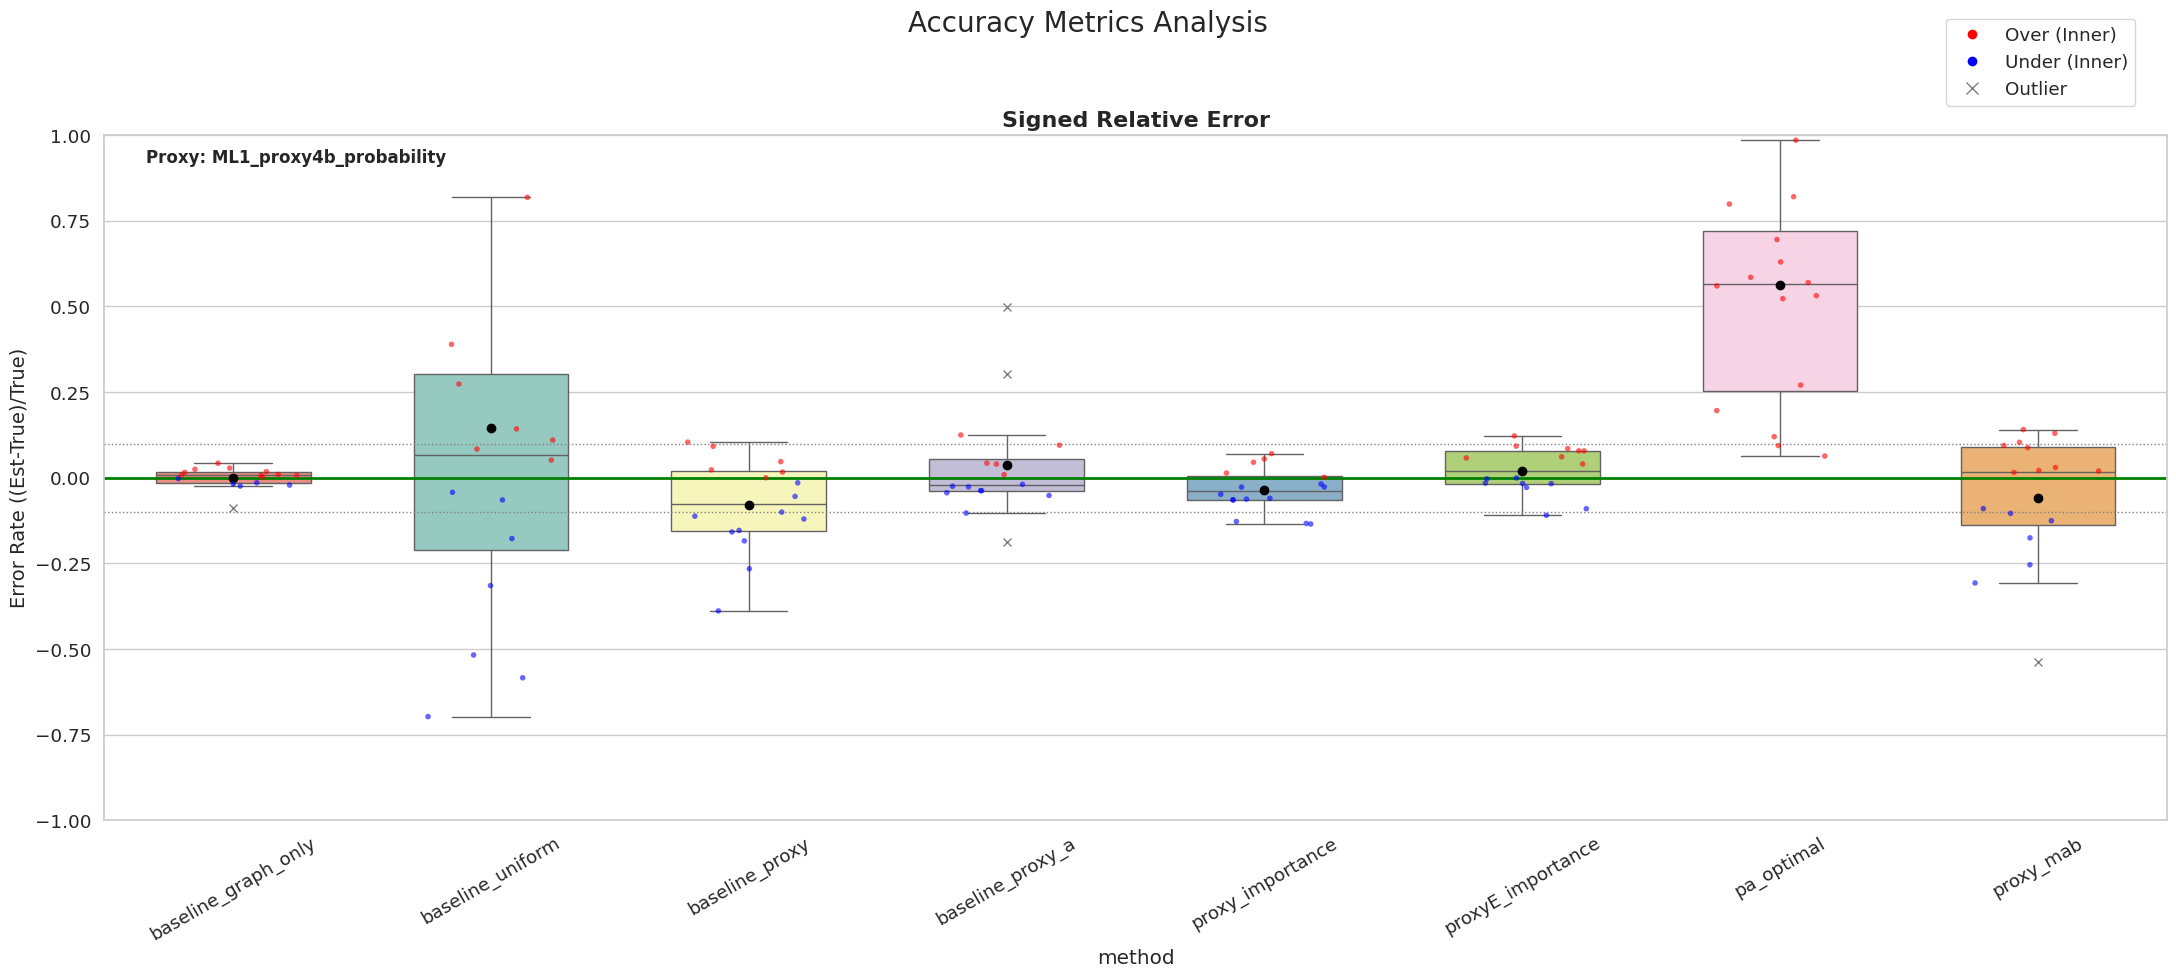

In [3]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import random
import time

# ==========================================
# 0. 全局配置
# ==========================================

# 图像大小设置 (宽, 高)
FIG_SIZE = (22, 10) 

# 是否显示箱内的散点
# SHOW_INNER_DOTS = False
SHOW_INNER_DOTS = True

# 是否绘制 Q-Error 图
SHOW_Q_ERROR_PLOT = False

# --- [关键修改] 随机种子设置 ---
# 作用：控制采样结果是否可复现
# - 设置为 整数 (例如 42): 每次运行采样的文件完全相同（结果可复现）。
# - 设置为 None: 每次运行采样的文件都不同（完全随机）。
RANDOM_SEED = 62225 
# RANDOM_SEED = None 

# 采样设置 (None 为使用全部)

SAMPLE_SIZE = 1
# 方法显示的顺序
METHOD_ORDER = [
    'baseline_graph_only', 
    'baseline_uniform', 
    'baseline_proxy', 
    'baseline_proxy_a', 
    'proxy_importance', 
    'proxyE_importance', 
] 

# 箱型图颜色主题
BOX_PALETTE = "Set3"

# ==========================================
# 1. 种子应用逻辑 (不要修改这里)
# ==========================================
if RANDOM_SEED is not None:
    print(f"[CONFIG] 检测到固定随机种子: {RANDOM_SEED} -> 采样结果将固定不变。")
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED) # 同时固定 numpy 的随机性，养成好习惯
else:
    print(f"[CONFIG] 随机种子为 None -> 每次采样结果将不同。")

# ==========================================
# 2. 定义核心计算与绘图函数
# ==========================================

def calculate_log_signed_q_error(row):
    """
    计算基于 Log2 的 Signed Q-Error
    """
    t = max(1.0, row['T_true']) 
    e = max(1.0, row['T_hat'])
    
    if e >= t:
        return np.log2(e / t)
    else:
        return -np.log2(t / e)

def load_data_from_dir(result_summarys_dir: str, dataset_name: str, proxy_model: str, sample_n: int = None) -> pd.DataFrame:
    """
    读取数据
    """
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        return pd.DataFrame()

    # --- 随机采样 ---
    # 注意：这里的 random.sample 会受到上面 random.seed(RANDOM_SEED) 的控制
    total_files = len(all_files)
    if sample_n and total_files > sample_n:
        selected_files = random.sample(all_files, sample_n)
        print(f"   [Sampling] 发现 {total_files} 个文件，随机采样 {sample_n} 个参与统计。")
    else:
        selected_files = all_files
        print(f"   [All Data] 发现 {total_files} 个文件，全部使用。")

    df_list = []
    for f in selected_files:
        try:
            tmp = pd.read_csv(f)
            
            # --- 提取查询名称 ---
            if 'query_basename' in tmp.columns:
                tmp['query_identifier'] = tmp['query_basename'].astype(str).apply(
                    lambda x: x.replace('.graph', '')
                )
            elif 'query_index' in tmp.columns:
                tmp['query_identifier'] = "idx_" + tmp['query_index'].astype(str)
            else:
                tmp['query_identifier'] = os.path.basename(f) + "_row" + tmp.index.astype(str)
            
            if 'T_true' not in tmp.columns or 'T_hat' not in tmp.columns:
                continue

            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取文件 {f} 失败: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)

    # 1. 计算 Signed Relative Error
    df["signed_relative_error"] = np.where(
        df["T_true"] != 0, 
        (df["T_hat"] - df["T_true"]) / df["T_true"],
        np.nan
    )

    # 2. 计算 Log Signed Q-Error
    df["log_signed_q_error"] = df.apply(calculate_log_signed_q_error, axis=1)
    
    # 3. 标记高估还是低估
    df["est_type"] = np.where(df["T_hat"] >= df["T_true"], "Over", "Under")

    df["proxy_model"] = proxy_model
    df["dataset_name"] = dataset_name
    
    return df.dropna(subset=["signed_relative_error", "log_signed_q_error"])

def analyze_and_print_outliers(df, metric_col, method_col="method", id_col="query_identifier"):
    """
    计算并打印异常值详情
    """
    print(f"\n{'='*20} 异常值分析: {metric_col} {'='*20}")
    
    existing_methods = set(df[method_col].unique())
    if METHOD_ORDER:
        methods_to_analyze = [m for m in METHOD_ORDER if m in existing_methods]
        remain = [m for m in df[method_col].unique() if m not in methods_to_analyze]
        methods_to_analyze.extend(remain)
    else:
        methods_to_analyze = sorted(list(existing_methods))

    for method in methods_to_analyze:
        subset = df[df[method_col] == method]
        if subset.empty: continue
        
        Q1 = subset[metric_col].quantile(0.25)
        Q3 = subset[metric_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = subset[(subset[metric_col] < lower_bound) | (subset[metric_col] > upper_bound)].copy()
        
        if not outliers.empty:
            outliers['abs_err'] = outliers[metric_col].abs()
            outliers = outliers.sort_values(by='abs_err', ascending=False)
            
            print(f"\n[Method: {method}] 检测到 {len(outliers)} 个奇异值 (Bounds: [{lower_bound:.4f}, {upper_bound:.4f}]):")
            
            top_n = outliers.head(15)
            for idx, row in top_n.iterrows():
                print(f"  - Query: {str(row[id_col]):<40} | Val: {row[metric_col]:.4f}")
                
            if len(outliers) > 15:
                print(f"  ... 还有 {len(outliers)-15} 个未显示")
        else:
            print(f"\n[Method: {method}] 无异常值。")
    print("="*60 + "\n")

def plot_dual_metrics_boxplot(df: pd.DataFrame, proxy_name: str, save_path: str = None):
    """
    绘制图表
    """
    if df.empty:
        return

    # 先分析相对误差的异常值
    analyze_and_print_outliers(df, "signed_relative_error", id_col="query_identifier")

    # --- 确定绘图顺序 ---
    available_methods = set(df["method"].unique())
    final_order = None
    if METHOD_ORDER and len(METHOD_ORDER) > 0:
        valid_config_methods = [m for m in METHOD_ORDER if m in available_methods]
        remaining_methods = [m for m in available_methods if m not in valid_config_methods]
        final_order = valid_config_methods + sorted(list(remaining_methods))
        if len(final_order) == 0: final_order = None
    else:
        final_order = sorted(list(available_methods))

    sns.set_theme(style="whitegrid", font_scale=1.2)
    
    # --- 根据配置决定子图数量 ---
    if SHOW_Q_ERROR_PLOT:
        fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
        ax1 = axes[0]
        ax2 = axes[1]
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=FIG_SIZE)
        ax2 = None

    palette_dots = {"Over": "red", "Under": "blue"}
    
    # --- 核心辅助函数：只画须内部的点 ---
    def plot_inner_strips(ax, data, x_col, y_col, order_list):
        if not SHOW_INNER_DOTS:
            return

        current_methods = order_list if order_list else sorted(data[x_col].unique())
        inner_data_list = []
        
        for m in current_methods:
            sub = data[data[x_col] == m]
            if sub.empty: continue
            
            Q1 = sub[y_col].quantile(0.25)
            Q3 = sub[y_col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            mask = (sub[y_col] >= lower) & (sub[y_col] <= upper)
            inner_data_list.append(sub[mask])
            
        if inner_data_list:
            inner_data = pd.concat(inner_data_list)
            sns.stripplot(
                data=inner_data, x=x_col, y=y_col, hue="est_type",
                palette=palette_dots, 
                order=order_list,
                jitter=0.25,  
                dodge=False,  
                alpha=0.6, size=4, ax=ax, legend=False 
            )

    # ==========================
    # 图1：Relative Error
    # ==========================
    sns.boxplot(
        data=df, x="method", y="signed_relative_error",
        hue="method", palette=BOX_PALETTE, dodge=False,
        order=final_order,
        showmeans=True, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6}, 
        whis=1.5,
        ax=ax1
    )
    plot_inner_strips(ax1, df, "method", "signed_relative_error", final_order)
    
    ax1.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (0.0)")
    ax1.axhline(0.1, color="gray", linestyle=":", linewidth=1)
    ax1.axhline(-0.1, color="gray", linestyle=":", linewidth=1)
    
    ax1.set_title(f"Signed Relative Error", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Error Rate ((Est-True)/True)", fontsize=14)
    ax1.set_ylim(-1.0, 1.0) 
    ax1.tick_params(axis='x', rotation=30)
    if ax1.get_legend(): ax1.get_legend().remove()
    
    ax1.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax1.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

    # ==========================
    # 图2：Log Signed Q-Error (按需)
    # ==========================
    if SHOW_Q_ERROR_PLOT and ax2 is not None:
        sns.boxplot(
            data=df, x="method", y="log_signed_q_error",
            hue="method", palette=BOX_PALETTE, dodge=False,
            order=final_order,
            showmeans=True, width=0.6,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
            flierprops={"marker": "x", "color": "gray", "markeredgecolor": "gray", "markersize": 6},
            whis=1.5,
            ax=ax2
        )
        plot_inner_strips(ax2, df, "method", "log_signed_q_error", final_order)

        ax2.axhline(0, color="green", linestyle="-", linewidth=2, label="Perfect (1x)")
        for i in [1, 2, 3]:
            ax2.axhline(i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax2.axhline(-i, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            
        ax2.set_title(f"Log2 Q-Error", fontsize=16, fontweight='bold')
        ax2.set_ylabel("Log2 Scale (Pos: Over, Neg: Under)\n1.0=2x, 2.0=4x, 3.0=8x", fontsize=14)
        ax2.set_ylim(-6, 6)
        ax2.yaxis.set_major_locator(ticker.MultipleLocator(1))
        ax2.tick_params(axis='x', rotation=30)
        if ax2.get_legend(): ax2.get_legend().remove()
        
        ax2.text(0.02, 0.98, f"Proxy: {proxy_name}", transform=ax2.transAxes, 
                 fontsize=12, fontweight='bold', verticalalignment='top',
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

    # 图例
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='x', color='gray', linestyle='None', markersize=8, label='Outlier')]
    if SHOW_INNER_DOTS:
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Under (Inner)'))
        legend_elements.insert(0, Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Over (Inner)'))
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    fig.suptitle(f"Accuracy Metrics Analysis", fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] 图表已保存至: {save_path}")
    
    plt.show()
    plt.close()

# ==========================================
# 2. 配置与执行
# ==========================================
dataset_name = "dataset_one" 
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# 采样设置


proxy_models = [
    'ML1_proxy4b_probability',

    # 'Dist_Beta_U_proxy2',
    # 'Dist_Asym_LeftHigh_proxy2',
    # 'Dist_Asym_RightHigh_proxy2',

    
    # 'Dist_Bimodal_proxy2',
    # 'Dist_Bimodal_left_proxy2',
    # 'Dist_Bimodal_right_proxy2',

    # 'Dist_SkewHigh_proxy2',
    # 'Dist_SkewLow_proxy2',

    # 'Dist_Extreme_Mix_proxy2',

]
print(f"[INFO] 图像尺寸: {FIG_SIZE}")
print(f"[INFO] 是否绘制 Q-Error 图: {SHOW_Q_ERROR_PLOT}")
print(f"[INFO] 随机种子: {RANDOM_SEED}")

for proxy in proxy_models:
    summarys_dir = os.path.join(output_dir, f"result_summarys/{proxy}")
    
    df_proxy = load_data_from_dir(summarys_dir, dataset_name, proxy, sample_n=SAMPLE_SIZE)
    
    if not df_proxy.empty:
        print(f"\n>>> 正在处理 Proxy: {proxy} (记录数: {len(df_proxy)})")
        
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        # 不同的种子或不同的采样，结合时间戳，文件不会冲突，且可追溯
        save_path = os.path.join(summarys_dir, f"{dataset_name}_metrics_analysis_{timestamp}.png")
        
        plot_dual_metrics_boxplot(df_proxy, proxy_name=proxy, save_path=save_path)
    else:
        print(f"[WARN] 跳过 {proxy} (无数据)")

### 6.1 修改/home/wangshuo/resource/datasets/parler_data/dataset_one/results/result_summarys/proxy_4b1下所有结果文件的列名： T_hat_mean ->T_hat , T_hat_std->n_post ，Qerror_mean->Qerror ，Qerror_std->n_comment

In [ ]:
from pathlib import Path
import pandas as pd
import shutil
import time
from typing import Dict, Tuple, Optional, Union

# =========================
# 列名映射关系
# =========================
COL_MAP = {
    "T_hat_mean": "T_hat",
    "T_hat_std": "n_post",
    "Qerror_mean": "Qerror",
    "Qerror_std": "n_comment",
}


def _process_one_csv(
    path: Path,
    col_map: Dict[str, str],
    backup_dir: Optional[Path],
    dry_run: bool,
    verbose: bool = True,
) -> Tuple[bool, str]:
    """
    处理单个 CSV 文件：重命名列并写回
    """
    if verbose:
        print(f"[INFO] 处理: {path}")

    # 读取 CSV
    try:
        df = pd.read_csv(path)
    except Exception as e:
        if verbose:
            print(f"  [ERROR] 读取失败: {e}")
        return False, "read_error"

    cols_before = list(df.columns)
    rename_map = {k: v for k, v in col_map.items() if k in df.columns}

    if not rename_map:
        if verbose:
            print("  [SKIP] 未发现需要替换的列。")
        return False, "no_change"

    if verbose:
        print(f"  列替换映射: {rename_map}")

    # dry-run 模式
    if dry_run:
        if verbose:
            print("  [DRY-RUN] 未实际写入。")
        return True, "dry_run"

    # 备份原文件
    if backup_dir is not None:
        backup_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(path, backup_dir / path.name)
        if verbose:
            print("  [BACKUP] 已备份")

    # 重命名并写回
    try:
        df = df.rename(columns=rename_map)

        # 保持原列顺序
        new_cols = [col_map.get(c, c) for c in cols_before]
        if set(new_cols) == set(df.columns):
            df = df.reindex(columns=new_cols)

        df.to_csv(path, index=False)

        if verbose:
            print("  [OK] 已写回")
        return True, "modified"

    except Exception as e:
        if verbose:
            print(f"  [ERROR] 写回失败: {e}")
        return False, "write_error"


def rename_result_summary_columns(
    target_path: Union[str, Path],
    col_map: Dict[str, str] = COL_MAP,
    backup: bool = True,
    dry_run: bool = False,
    recursive: bool = False,
    verbose: bool = True,
) -> Dict[str, int]:
    """
    在 Jupyter 中批量重命名 result_summary CSV 列名（Python 3.8 兼容）

    Parameters
    ----------
    target_path : str or Path
        目标目录或单个 CSV 文件
    col_map : dict
        列名映射
    backup : bool
        是否备份原文件
    dry_run : bool
        仅打印，不写文件
    recursive : bool
        是否递归子目录
    verbose : bool
        是否打印日志
    """

    target = Path(target_path)
    if not target.exists():
        raise FileNotFoundError(f"路径不存在: {target}")

    # 收集 CSV 文件
    if target.is_file() and target.suffix.lower() == ".csv":
        files = [target]
    else:
        files = list(target.rglob("*.csv")) if recursive else list(target.glob("*.csv"))

    if not files:
        if verbose:
            print("[WARN] 未找到任何 CSV 文件。")
        return {}

    if verbose:
        print(f"[INFO] 找到 {len(files)} 个 CSV 文件")

    # 备份目录
    backup_dir = None
    if backup and not dry_run:
        ts = time.strftime("%Y%m%d_%H%M%S")
        backup_dir = target.parent / f"backup_result_summarys_{ts}"
        if verbose:
            print(f"[INFO] 备份目录: {backup_dir}")

    summary = {
        "modified": 0,
        "skipped": 0,
        "dry_run": 0,
        "errors": 0,
    }

    # 批量处理
    for f in files:
        _, status = _process_one_csv(
            path=f,
            col_map=col_map,
            backup_dir=backup_dir,
            dry_run=dry_run,
            verbose=verbose,
        )

        if status == "modified":
            summary["modified"] += 1
        elif status == "no_change":
            summary["skipped"] += 1
        elif status == "dry_run":
            summary["dry_run"] += 1
        else:
            summary["errors"] += 1

    if verbose:
        print("\n[SUMMARY]")
        for k, v in summary.items():
            print(f"  {k}: {v}")

    return summary

dataset_name = "dataset_three"
proxy_model = "proxy4b"
rename_result_summary_columns(
    target_path=f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/result_summarys/{proxy_model}",
    backup=True,
    dry_run=False,
    recursive=False,
)



### 7.分析处理异常的项

#### 7.1 基数估计偏离图

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

# ==========================================
# 1. 配置与数据加载函数 (复用之前的逻辑)
# ==========================================
dataset_name = "dataset_three"
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"
# 这里填入你想要分析的 Proxy 模型名称
proxy_models = ['ML1_proxy4b1_probability'] 

def load_data_for_analysis(result_summarys_dir, dataset_name, proxy_model):
    """加载数据用于分析，确保包含 query_name"""
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        print(f"[WARN] 未找到文件: {pattern}")
        return pd.DataFrame()

    df_list = []
    for f in all_files:
        try:
            tmp = pd.read_csv(f)
            # 关键：确保 query_name 存在。如果 CSV 里叫 'query' 或其他名字，这里做个重命名
            # 假设 CSV 里第一列或者是 'query_name'
            if 'query_basename' not in tmp.columns and 'query' in tmp.columns:
                tmp.rename(columns={'query': 'query_basename'}, inplace=True)
            
            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取失败 {f}: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)
    
    # 计算误差指标 (复用之前的逻辑)
    t = np.maximum(df['T_true'].astype(float).fillna(0), 1.0)
    e = np.maximum(df['T_hat'].astype(float).fillna(0), 1.0)
    
    df['signed_relative_error'] = (e - t) / t
    
    # 计算 Signed Log2 Q-Error
    ratio = e / t
    df['signed_log2_qerror'] = np.where(ratio >= 1.0, np.log2(ratio), -np.log2(1.0 / ratio))
    
    df['proxy_model'] = proxy_model
    return df

# ==========================================
# 2. 定义离群点分析函数
# ==========================================
def analyze_outliers(df, metric='signed_relative_error', method=None, top_k=20):
    """
    分析并可视化离群点
    """
    # 1. 筛选数据
    data = df.copy()
    if method:
        data = data[data['method'] == method]
    
    # 移除空值
    data = data.dropna(subset=[metric])
    
    if data.empty:
        print("没有有效数据可分析。")
        return

    # 2. 找出误差绝对值最大的 Top K
    data['abs_error'] = data[metric].abs()
    outliers = data.sort_values(by='abs_error', ascending=False).head(top_k)
    
    print(f"\n{'='*60}")
    print(f"Top {top_k} 离群点分析 | Metric: {metric} | Method: {method if method else 'ALL'}")
    print(f"{'='*60}")
    
    # 打印表格
    cols = ['method', 'query_basename', 'T_true', 'T_hat', metric]
    # 仅显示存在的列
    show_cols = [c for c in cols if c in data.columns]
    print(outliers[show_cols].to_string(index=False))
    
    # 3. 绘图：误差 vs 真实基数
    plt.figure(figsize=(12, 6))
    
    # 绘制所有点（灰色背景）
    sns.scatterplot(data=data, x='T_true', y=metric, color='lightgray', alpha=0.5, label='Normal', s=30)
    
    # 高亮离群点（红色）
    sns.scatterplot(data=outliers, x='T_true', y=metric, color='red', s=100, marker='X', label='Top Outliers')
    
    # 标注离群点的 query_name
    for i, row in outliers.iterrows():
        # 稍微偏移一点文本，避免重叠
        plt.text(row['T_true'], row[metric], row['query_basename'], fontsize=9, color='black', ha='right')

    plt.xscale('log') # 基数通常跨度大，用对数轴
    plt.axhline(0, color='blue', linestyle='--', linewidth=1)
    plt.title(f'Outlier Analysis: {metric} vs. True Cardinality')
    plt.xlabel('True Cardinality (Log Scale)')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. 执行调用
# ==========================================

# A. 加载数据
print("正在加载数据...")
all_dfs = []
for proxy in proxy_models:
    path = os.path.join(output_dir, f"result_summarys/{proxy}")
    df_tmp = load_data_for_analysis(path, dataset_name, proxy)
    if not df_tmp.empty:
        all_dfs.append(df_tmp)

if all_dfs:
    df_all = pd.concat(all_dfs, ignore_index=True)
    print(f"数据加载完成，共 {len(df_all)} 条记录。")
    
    # B. 运行分析
    # 示例 1: 分析 Signed Relative Error 最大的异常点
    analyze_outliers(df_all, metric='signed_relative_error', top_k=10)
    
    # 示例 2: 分析 Signed Log2 Q-Error 最大的异常点 (如果想看倍数误差)
    analyze_outliers(df_all, metric='signed_log2_qerror', top_k=10)
    
else:
    print("未加载到任何数据，请检查路径配置。")

#### 7.2 基数估计偏离图--各个方法

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import random  # 引入 random 用于采样

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = "dataset_three"
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"
proxy_models = ['ML1_proxy4b1_probability'] 

# [新增] 采样数量配置
# 设置为具体的数字（如 12）则随机抽取该数量的文件；
# 设置为 None 则读取所有文件。
SAMPLE_SIZE = 5

# ==========================================
# 2. 数据加载函数 (含采样逻辑)
# ==========================================
def load_data_for_analysis(result_summarys_dir, dataset_name, proxy_model, sample_size=None):
    """加载数据用于分析，支持随机采样"""
    pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
    all_files = glob.glob(pattern)
    
    if not all_files:
        print(f"[WARN] 未找到文件: {pattern}")
        return pd.DataFrame()

    # --- 采样逻辑 ---
    total_files = len(all_files)
    if sample_size and total_files > sample_size:
        selected_files = random.sample(all_files, sample_size)
        print(f"[Sampling] 在 {proxy_model} 中发现 {total_files} 个文件，随机采样 {sample_size} 个参与统计。")
    else:
        selected_files = all_files
        print(f"[All Data] 在 {proxy_model} 中发现 {total_files} 个文件，全部使用。")

    df_list = []
    for f in selected_files:
        try:
            tmp = pd.read_csv(f)
            
            # --- 统一列名与清洗 ---
            # 1. 确保 query_basename 存在
            if 'query_basename' not in tmp.columns:
                if 'query' in tmp.columns:
                    tmp.rename(columns={'query': 'query_basename'}, inplace=True)
                else:
                    # 如果没有名字，用文件名+行号代替
                    tmp['query_basename'] = os.path.basename(f) + "_row" + tmp.index.astype(str)
            
            # 2. 清洗 .graph 后缀 (为了输出好看)
            tmp['query_basename'] = tmp['query_basename'].astype(str).apply(lambda x: x.replace('.graph', ''))

            df_list.append(tmp)
        except Exception as e:
            print(f"[WARN] 读取失败 {f}: {e}")
    
    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)
    
    # --- 计算误差指标 ---
    # 填充空值并确保不除以0
    t = np.maximum(df['T_true'].astype(float).fillna(0), 1.0)
    e = np.maximum(df['T_hat'].astype(float).fillna(0), 1.0)
    
    # 1. Signed Relative Error
    df['signed_relative_error'] = (e - t) / t
    
    # 2. Signed Log2 Q-Error
    # e >= t: log2(e/t); e < t: -log2(t/e)
    ratio = e / t
    df['signed_log2_qerror'] = np.where(ratio >= 1.0, np.log2(ratio), -np.log2(1.0 / ratio))
    
    df['proxy_model'] = proxy_model
    return df

# ==========================================
# 3. 离群点分析函数 (基于 IQR)
# ==========================================
def analyze_boxplot_outliers_and_print_all(df, metric='signed_relative_error'):
    """
    基于箱型图定义 (IQR) 识别并输出所有奇异值
    """
    if df.empty:
        print("没有有效数据可分析。")
        return

    # 按 method 分组分析，因为不同方法的分布不同，奇异值判定标准也不同
    methods = df['method'].unique()
    
    print(f"\n{'='*80}")
    print(f"全量奇异值输出 (Based on Boxplot IQR Rules) | Metric: {metric}")
    print(f"{'='*80}")

    for method in methods:
        data = df[df['method'] == method].copy()
        data = data.dropna(subset=[metric])
        
        if data.empty: continue

        # 1. 计算 IQR 边界
        Q1 = data[metric].quantile(0.25)
        Q3 = data[metric].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 2. 筛选奇异值 (在须之外的点)
        outliers = data[(data[metric] < lower_bound) | (data[metric] > upper_bound)].copy()

        # 3. 排序：按误差绝对值从大到小
        outliers['abs_metric'] = outliers[metric].abs()
        outliers = outliers.sort_values(by='abs_metric', ascending=False)
        
        count = len(outliers)
        print(f"\n>>> Method: [{method}]")
        print(f"    统计: 总样本 {len(data)} | 奇异值 {count} 个")
        print(f"    边界: [{lower_bound:.4f}, {upper_bound:.4f}] (IQR={IQR:.4f})")
        
        if count > 0:
            print(f"    {'Query Name':<45} | {'Val':<10} | {'True Card':<10} | {'Est Card':<10}")
            print(f"    {'-'*85}")
            
            # 全部输出
            for idx, row in outliers.iterrows():
                q_name = str(row['query_basename'])
                # 截断过长的名字以便显示
                if len(q_name) > 42: q_name = q_name[:42] + ".."
                
                print(f"    {q_name:<45} | {row[metric]:<10.4f} | {int(row['T_true']):<10} | {int(row['T_hat']):<10}")
        else:
            print("    (无奇异值)")

# ==========================================
# 4. 辅助绘图函数 (可选，用于直观验证)
# ==========================================
def plot_diagnostic_scatter(df, metric='signed_relative_error'):
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    
    # 绘制散点：X轴为真实基数，Y轴为误差
    sns.scatterplot(
        data=df, 
        x='T_true', 
        y=metric, 
        hue='method', 
        style='method',
        alpha=0.7,
        s=60
    )
    
    plt.xscale('log') # 基数跨度大，使用对数轴
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    # 标注 Top 5 最严重的点
    df['abs_err'] = df[metric].abs()
    top_outliers = df.sort_values('abs_err', ascending=False).head(5)
    for i, row in top_outliers.iterrows():
        plt.text(row['T_true'], row[metric], row['query_basename'], fontsize=8, color='red')

    plt.title(f'Diagnostic Plot: {metric} vs. True Cardinality')
    plt.xlabel('True Cardinality (Log Scale)')
    plt.ylabel(metric)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. 主程序执行
# ==========================================
if __name__ == "__main__":
    print(f"[INFO] 采样配置: SAMPLE_SIZE = {SAMPLE_SIZE if SAMPLE_SIZE else 'All'}")
    
    # A. 加载数据
    all_dfs = []
    for proxy in proxy_models:
        path = os.path.join(output_dir, f"result_summarys/{proxy}")
        df_tmp = load_data_for_analysis(path, dataset_name, proxy, sample_size=SAMPLE_SIZE)
        if not df_tmp.empty:
            all_dfs.append(df_tmp)

    if all_dfs:
        df_all = pd.concat(all_dfs, ignore_index=True)
        print(f"\n[INFO] 数据加载完成，共 {len(df_all)} 条记录。开始分析...\n")
        
        # B. 运行核心任务：输出相对误差箱型图对应的所有奇异值
        # 这里的 metric 对应相对误差
        analyze_boxplot_outliers_and_print_all(df_all, metric='signed_relative_error')
        
        # C. (可选) 如果你也想看 Q-Error 的奇异值，取消下面注释
        # analyze_boxplot_outliers_and_print_all(df_all, metric='signed_log2_qerror')

        # D. (可选) 绘制诊断散点图
        # plot_diagnostic_scatter(df_all, metric='signed_relative_error')
        
    else:
        print("[ERROR] 未加载到任何数据，请检查路径配置。")

#### 7.3 各方法找失效规律

7.3.1 我只想单独查看一个方法，在SAMPLE_SIZE = 10 次运行后，有哪些查询失效的次数大于5,并且对每次失效的误差去绝对值后取均值，按这个均值排列查询名

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import random

# ==========================================
# 0. 配置参数
# ==========================================
dataset_name = "dataset_three"
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# --- [配置 1] 数据源目录 ---
SOURCE_DIRS = [
    'ML1_proxy4b1_probability', 
]

# 采样设置: 10 次运行
SAMPLE_SIZE = 20 

# --- [配置 2] 目标方法 ---
TARGET_METHOD = 'proxy_importance'

# 失效判定阈值 (失效次数必须 > 此值)
FAILURE_COUNT_THRESHOLD = 3

# ==========================================
# 1. 数据加载函数
# ==========================================
def load_data_from_sources(base_dir, source_dirs, dataset_name, sample_size=None):
    all_dfs = []
    for source in source_dirs:
        result_summarys_dir = os.path.join(base_dir, f"result_summarys/{source}")
        pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
        all_files = glob.glob(pattern)
        
        if not all_files: continue

        # 采样逻辑
        if sample_size and len(all_files) > sample_size:
            selected_files = random.sample(all_files, sample_size)
            print(f"[Sampling] 源 [{source}]: 随机采样 {sample_size}/{len(all_files)} 个文件。")
        else:
            selected_files = all_files
            print(f"[All Data] 源 [{source}]: 加载全部 {len(all_files)} 个文件。")

        df_list = []
        for f in selected_files:
            try:
                tmp = pd.read_csv(f)
                if 'query_basename' not in tmp.columns:
                    if 'query' in tmp.columns:
                        tmp.rename(columns={'query': 'query_basename'}, inplace=True)
                    else:
                        tmp['query_basename'] = os.path.basename(f) + "_row" + tmp.index.astype(str)
                tmp['query_basename'] = tmp['query_basename'].astype(str).apply(lambda x: x.replace('.graph', ''))
                df_list.append(tmp)
            except Exception:
                pass
        
        if df_list:
            all_dfs.append(pd.concat(df_list, ignore_index=True))

    if not all_dfs: return pd.DataFrame()
    
    df = pd.concat(all_dfs, ignore_index=True)
    df['T_true'] = df['T_true'].fillna(0).astype(float)
    df['T_hat'] = df['T_hat'].fillna(0).astype(float)
    denom = df['T_true'].copy()
    denom[denom == 0] = 1.0 
    df['signed_relative_error'] = (df['T_hat'] - df['T_true']) / denom
    
    return df

# ==========================================
# 2. 单方法深入分析函数
# ==========================================
def analyze_single_method_failures(df, method_name, threshold_count=5):
    """
    分析单个方法的顽固失效查询，并按失效时的平均严重程度排序。
    """
    print(f"\n{'='*80}")
    print(f"【深度分析】方法: {method_name}")
    print(f"筛选条件: 在 {SAMPLE_SIZE} 次运行中，失效次数 > {threshold_count}")
    print(f"排序依据: 仅计算'失效'状态下的平均绝对误差 (Mean Abs Error of Failures)")
    print(f"{'='*80}")

    # 1. 提取该方法的数据
    sub = df[df['method'] == method_name].copy()
    if sub.empty:
        print(f"[ERROR] 找不到方法 '{method_name}' 的数据。")
        return

    # 2. 计算全局 IQR 边界 (定义什么是"失效")
    metric = 'signed_relative_error'
    Q1 = sub[metric].quantile(0.25)
    Q3 = sub[metric].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f"全局 IQR 统计:")
    print(f"  Q1: {Q1:.4f}, Q3: {Q3:.4f}, IQR: {IQR:.4f}")
    print(f"  失效判定边界: < {lower_bound:.4f} 或 > {upper_bound:.4f}\n")

    # 3. 标记单次运行是否失效
    sub['is_outlier'] = (sub[metric] < lower_bound) | (sub[metric] > upper_bound)
    
    # 4. 按查询分组统计
    query_stats = sub.groupby('query_basename')['is_outlier'].agg(['count', 'sum'])
    query_stats.rename(columns={'count': 'total_runs', 'sum': 'fail_count'}, inplace=True)
    
    # 5. 筛选顽固查询 (失效次数 > 阈值)
    target_queries_index = query_stats[query_stats['fail_count'] > threshold_count].index
    
    if len(target_queries_index) == 0:
        print("未发现满足筛选条件的顽固失效查询。")
        return
    
    print(f"发现 {len(target_queries_index)} 个顽固失效查询。正在计算排序指标...\n")

    # --- [新增] 预先提取每个查询的真实基数 (True Card) ---
    # 因为同一个查询的 True Card 是固定的，我们取最大值或第一个值即可
    query_true_cards = sub.groupby('query_basename')['T_true'].max()

    # 6. 计算排序指标
    target_rows = sub[sub['query_basename'].isin(target_queries_index)].copy()
    failure_rows = target_rows[target_rows['is_outlier'] == True].copy()
    failure_rows['abs_error'] = failure_rows[metric].abs()
    ranking_score = failure_rows.groupby('query_basename')['abs_error'].mean()
    ranking_score = ranking_score.sort_values(ascending=False)
    
    # 7. 打印结果 (增加了 True Card 列)
    print(f"{'Rank':<5} | {'Query Name':<40} | {'True Card':<10} | {'Fail/Total':<10} | {'Avg Abs Err (Failures Only)'}")
    print("-" * 115)
    
    for rank, (q_name, score) in enumerate(ranking_score.items(), 1):
        # 获取统计信息
        stats = query_stats.loc[q_name]
        fail_ratio_str = f"{int(stats['fail_count'])}/{int(stats['total_runs'])}"
        
        # 获取真实基数
        t_val = query_true_cards.get(q_name, 0)
        
        print(f"{rank:<5} | {q_name:<40} | {int(t_val):<10} | {fail_ratio_str:<10} | {score:.4f}")
        
        if rank >= 50:
            print(f"... (剩余 {len(ranking_score)-50} 条未显示)")
            break

# ==========================================
# 3. 主程序
# ==========================================
if __name__ == "__main__":
    # 加载数据
    df_raw = load_data_from_sources(output_dir, SOURCE_DIRS, dataset_name, sample_size=SAMPLE_SIZE)

    if not df_raw.empty:
        # 执行分析
        analyze_single_method_failures(
            df_raw, 
            method_name=TARGET_METHOD, 
            threshold_count=FAILURE_COUNT_THRESHOLD
        )
    else:
        print("[ERROR] 未加载到数据。")

下一步找各个方法都失效的查询，或者说在不少方法均失效的查询，同时单独列举出所有Est Card =0 的查询有哪些，且哪个方法预测的是0

加严共同失效的条件，SAMPLE_SIZE = n 的话，必须有n/2次，同时失效才算该查询失效：
修改逻辑说明：
不再只看单次运行：之前的逻辑是只要有一次 Run 是奇异值，该查询就被标记。
引入“多数投票”机制 (n/2 规则)：
先计算该方法下所有数据的全局 IQR 边界。
对每个查询，统计它有多少个 Run 跑出了这个边界。
只有当 (跑出边界的次数 / 该查询的总 Run 数) 
 时，才判定该查询为该方法的“失效查询”。
显示优化：在最后输出详情时，不再取第一次运行的值，而是计算该查询所有 Run 的 平均误差，这样能更准确地反映它的偏离程度。

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import random

# ==========================================
# 0. 配置参数
# ==========================================
dataset_name = "dataset_three"
output_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results"

# --- [配置 1] 数据源目录 ---
SOURCE_DIRS = [
    'ML1_proxy4b1_probability', 
]

# 采样设置 (整数: 随机抽取文件数; None: 使用全部)
# 如果设为 20，那么判定失效需要至少 10 个文件也是失效的
SAMPLE_SIZE = 10 

# --- [配置 2] 共同失效分析的目标方法 ---
TARGET_METHODS_FOR_JOINT_FAILURE = [
    'proxy_importance',
]

# ==========================================
# 1. 数据加载函数
# ==========================================
def load_data_from_sources(base_dir, source_dirs, dataset_name, sample_size=None):
    all_dfs = []
    
    for source in source_dirs:
        result_summarys_dir = os.path.join(base_dir, f"result_summarys/{source}")
        pattern = os.path.join(result_summarys_dir, "results_summary_run_*.csv")
        all_files = glob.glob(pattern)
        
        if not all_files:
            continue

        if sample_size and len(all_files) > sample_size:
            selected_files = random.sample(all_files, sample_size)
            print(f"[Sampling] 源 [{source}]: 随机采样 {sample_size}/{len(all_files)} 个文件。")
        else:
            selected_files = all_files
            print(f"[All Data] 源 [{source}]: 加载全部 {len(all_files)} 个文件。")

        df_list = []
        for f in selected_files:
            try:
                tmp = pd.read_csv(f)
                if 'query_basename' not in tmp.columns:
                    if 'query' in tmp.columns:
                        tmp.rename(columns={'query': 'query_basename'}, inplace=True)
                    else:
                        tmp['query_basename'] = os.path.basename(f) + "_row" + tmp.index.astype(str)
                
                tmp['query_basename'] = tmp['query_basename'].astype(str).apply(lambda x: x.replace('.graph', ''))
                df_list.append(tmp)
            except Exception:
                pass
        
        if df_list:
            all_dfs.append(pd.concat(df_list, ignore_index=True))

    if not all_dfs:
        return pd.DataFrame()
    
    df = pd.concat(all_dfs, ignore_index=True)
    
    df['T_true'] = df['T_true'].fillna(0).astype(float)
    df['T_hat'] = df['T_hat'].fillna(0).astype(float)
    
    denom = df['T_true'].copy()
    denom[denom == 0] = 1.0 
    df['signed_relative_error'] = (df['T_hat'] - df['T_true']) / denom
    
    return df

# ==========================================
# 2. 专题分析：预测为 0 的查询
# ==========================================
def analyze_zero_estimates(df):
    print(f"\n{'='*80}")
    print(f"【专题分析 1】: 预测值为 0 (Est Card = 0) 的查询列表")
    print(f"{'='*80}")
    
    zeros = df[df['T_hat'] == 0].copy()
    
    if zeros.empty:
        print("未发现任何预测值为 0 的记录。")
        return

    # 为了避免同一查询多个Run重复刷屏，这里按查询去重，取 T_true 最大的
    unique_zeros = zeros.drop_duplicates(subset=['method', 'query_basename']).sort_values(by='T_true', ascending=False)
    
    print(f"共发现 {len(zeros)} 条记录预测为 0 (去重后 {len(unique_zeros)} 个查询-方法对)。")
    print(f"{'Method':<25} | {'Query Name':<45} | {'True Card':<10} | {'Type'}")
    print("-" * 100)
    
    count = 0
    for idx, row in unique_zeros.iterrows():
        err_type = "Correct" if row['T_true'] == 0 else "FATAL ERROR"
        print(f"{row['method']:<25} | {row['query_basename']:<45} | {int(row['T_true']):<10} | {err_type}")
        count += 1
        if count >= 30: 
            print(f"... (剩余隐藏)")
            break

# ==========================================
# 3. [核心修改] 严格的奇异值判定 (n/2 规则)
# ==========================================
def get_strict_outliers_for_method(df, method_name, metric='signed_relative_error'):
    """
    加严判断：只有当一个查询在 >= 50% 的 Run 中都是奇异值时，才算该查询失效。
    """
    sub = df[df['method'] == method_name].copy()
    if sub.empty:
        print(f"[WARN] 数据中找不到方法 '{method_name}'。")
        return set()
    
    # 1. 计算该方法全局的 IQR 边界 (基于所有 Run 的分布)
    Q1 = sub[metric].quantile(0.25)
    Q3 = sub[metric].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 2. 标记每一行是否为奇异值
    sub['is_outlier'] = (sub[metric] < lower_bound) | (sub[metric] > upper_bound)
    
    # 3. 按查询分组，统计失效次数
    # count() 统计总 Run 数，sum() 统计失效 Run 数
    query_stats = sub.groupby('query_basename')['is_outlier'].agg(['count', 'sum'])
    
    # 4. 应用 n/2 规则
    # 失效比例 >= 0.5
    query_stats['failure_rate'] = query_stats['sum'] / query_stats['count']
    failed_queries = query_stats[query_stats['failure_rate'] >= 0.2]
    
    count_total_queries = len(query_stats)
    count_failed = len(failed_queries)
    
    print(f"  > 方法 [{method_name}]: 边界 [{lower_bound:.4f}, {upper_bound:.4f}]")
    print(f"    - 总查询数: {count_total_queries}")
    print(f"    - 严格失效查询数 (Fail Rate >= 50%): {count_failed}")
    
    return set(failed_queries.index)

def analyze_joint_boxplot_outliers(df, target_methods):
    print(f"\n{'='*80}")
    print(f"【专题分析 2】: 共同失效分析 (Strict Joint Failure)")
    print(f"判定标准 1 (单方法): 查询在 >50% 的 Run 中超出须(Whisker)范围")
    print(f"判定标准 2 (共同): 查询满足标准1 于 所有目标方法")
    print(f"{'='*80}")
    
    if not target_methods:
        return

    method_outlier_sets = {}
    valid_targets = []

    for method in target_methods:
        if method not in df['method'].unique():
            continue
        valid_targets.append(method)
        # 使用严格判定函数
        outliers = get_strict_outliers_for_method(df, method)
        method_outlier_sets[method] = outliers

    if not method_outlier_sets:
        return

    # 计算交集
    common_failures = set.intersection(*method_outlier_sets.values())
    
    print(f"\n>>> 严格共同失效查询总数: {len(common_failures)}")
    
    if len(common_failures) > 0:
        print(f"\n{'Query Name':<45} | {'True Card':<10} | {'Details (Mean RelErr)'}")
        print("-" * 100)
        
        sorted_failures = sorted(list(common_failures))
        
        # 预计算平均误差，以便在打印时显示更有代表性的数值
        # 只计算涉及到的查询和方法
        relevant_df = df[
            (df['query_basename'].isin(common_failures)) & 
            (df['method'].isin(valid_targets))
        ]
        mean_errors = relevant_df.groupby(['query_basename', 'method'])['signed_relative_error'].mean()

        limit = 1000
        for i, q_name in enumerate(sorted_failures):
            if i >= limit:
                print(f"... 还有 {len(sorted_failures) - limit} 个查询未显示")
                break

            details = []
            true_card_display = "N/A"
            
            # 这里的 True Card 我们随便取该查询的一行即可
            try:
                t_val = df[df['query_basename'] == q_name].iloc[0]['T_true']
                true_card_display = int(t_val)
            except:
                pass
            
            for method in valid_targets:
                try:
                    # 获取该查询在该方法下的平均误差
                    avg_val = mean_errors.loc[(q_name, method)]
                    details.append(f"{method[:10]}:{avg_val:.2f}")
                except KeyError:
                    details.append(f"{method[:10]}:N/A")
            
            details_str = ", ".join(details)
            print(f"{q_name:<45} | {true_card_display:<10} | {details_str}")
            
    else:
        print("未发现共同失效的查询。")

# ==========================================
# 4. 主程序
# ==========================================
if __name__ == "__main__":
    print(f"=== 开始分析 | Sample Size: {SAMPLE_SIZE} ===\n")
    
    # 加载原始数据 (包含所有 Run)
    df_raw = load_data_from_sources(output_dir, SOURCE_DIRS, dataset_name, sample_size=SAMPLE_SIZE)

    if not df_raw.empty:
        print(f"数据加载完成，总行数: {len(df_raw)}")
        
        # 分析 1: 0值预测 (直接用原始数据即可)
        analyze_zero_estimates(df_raw)
        
        # 分析 2: 严格共同失效 (内部会处理 n/2 逻辑)
        analyze_joint_boxplot_outliers(df_raw, target_methods=TARGET_METHODS_FOR_JOINT_FAILURE)
        
    else:
        print("[ERROR] 未加载到任何数据。")

#### 7.0 评估结果分析：找到特殊的查询 
读取下面文件内容
dataset_name = "dataset_two"
csv_file = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/results_summary.csv"，
找到所有 baseline_proxy_a 方法Qerror_mean大于proxy_importance 的查询打印出来
找到所有 baseline_proxy_a 方法Qerror_mean大于proxyE_importance 的查询打印出来

In [ ]:
import pandas as pd

dataset_name = "dataset_three"
csv_file = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/results_summary.csv"

# 读取结果文件
df = pd.read_csv(csv_file)

# 检查必要列
required_cols = {"query_basename", "method", "Qerror_mean"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"缺少必要列: {required_cols - set(df.columns)}")

# 透视表：每个查询一行，每种方法一列
pivot_df = df.pivot_table(index="query_basename", columns="method", values="Qerror_mean")

# ===== 1️⃣ baseline_proxy_a > proxy_importance =====
cond1 = pivot_df["baseline_proxy_a"] < pivot_df["proxy_importance"]
worse_than_proxy_importance = pivot_df[cond1].reset_index()

print("\n===== 🚨 baseline_proxy_a 比 proxy_importance 更差的查询 =====")
if worse_than_proxy_importance.empty:
    print("✅ 没有发现更差的查询！")
else:
    for _, row in worse_than_proxy_importance.iterrows():
        print(f"{row['query_basename']}: "
              f"baseline_proxy_a={row['baseline_proxy_a']:.6f}, "
              f"proxy_importance={row['proxy_importance']:.6f}")
    print(f"\n🔢 总计 {len(worse_than_proxy_importance)} 个查询 baseline_proxy_a 的 Qerror_mean 更大。")

# ===== 2️⃣ baseline_proxy_a > proxyE_importance =====
cond2 = pivot_df["baseline_proxy_a"] < pivot_df["proxyE_importance"]
worse_than_proxyE_importance = pivot_df[cond2].reset_index()

print("\n===== 🚨 baseline_proxy_a 比 proxyE_importance 更差的查询 =====")
if worse_than_proxyE_importance.empty:
    print("✅ 没有发现更差的查询！")
else:
    for _, row in worse_than_proxyE_importance.iterrows():
        print(f"{row['query_basename']}: "
              f"baseline_proxy_a={row['baseline_proxy_a']:.6f}, "
              f"proxyE_importance={row['proxyE_importance']:.6f}")
    print(f"\n🔢 总计 {len(worse_than_proxyE_importance)} 个查询 baseline_proxy_a 的 Qerror_mean 更大。")

# ===== 3️⃣ 总结统计 =====
total_queries = len(pivot_df)
count_1 = len(worse_than_proxy_importance)
count_2 = len(worse_than_proxyE_importance)

print("\n===== 📊 汇总统计 =====")
print(f"总查询数: {total_queries}")
print(f"baseline_proxy_a 比 proxy_importance 更差的数量: {count_1} ({count_1/total_queries:.1%})")
print(f"baseline_proxy_a 比 proxyE_importance 更差的数量: {count_2} ({count_2/total_queries:.1%})")
